# 📊 Complete EDA Process (Refactored)
This notebook organizes EDA into functions for reusability and includes detailed explanations for each step.

## 1️⃣ General Utility Functions

In [ ]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objs as go

# Display all columns
pd.set_option('display.max_columns', None)

# Function to get basic dataset info
def basic_info(df):
    """
    Print basic info of a DataFrame: shape, types, and head.
    """
    print("Shape:", df.shape)
    print("\nData types:")
    print(df.dtypes)
    print("\nFirst 5 rows:")
    display(df.head())

# Function to summarize missing values
def missing_values_summary(df):
    """
    Display missing value count and percentage for each column.
    """
    missing = df.isnull().sum()
    percent = (missing / len(df)) * 100
    missing_df = pd.DataFrame({'Missing Values': missing, 'Percentage': percent})
    display(missing_df[missing_df['Missing Values'] > 0].sort_values('Percentage', ascending=False))

# Function to get numeric column statistics
def describe_numeric(df):
    """
    Display summary statistics for numeric columns.
    """
    display(df.describe())


## 2️⃣ Visualization Functions

In [ ]:
# Function to plot distribution of numeric columns
def plot_distributions(df, columns):
    """
    Plot histograms for the given list of numeric columns.
    """
    for col in columns:
        plt.figure(figsize=(8, 4))
        sns.histplot(df[col].dropna(), kde=True)
        plt.title(f'Distribution of {col}')
        plt.show()

# Function to plot correlation heatmap
def correlation_heatmap(df):
    """
    Plot correlation heatmap for numeric variables.
    """
    plt.figure(figsize=(10, 8))
    sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
    plt.title('Correlation Heatmap')
    plt.show()

# Function to create interactive scatter plot
def interactive_scatter(df, x, y, color=None):
    """
    Plot interactive scatter plot using Plotly.
    """
    fig = px.scatter(df, x=x, y=y, color=color, title=f'{y} vs {x}')
    fig.show()


## 3️⃣ Example Workflow on Your Dataset

In [ ]:
# Load your dataset (replace this path with your file)
# df = pd.read_csv('your_file.csv')

# Example usage
# basic_info(df)
# missing_values_summary(df)
# describe_numeric(df)
# plot_distributions(df, ['column1', 'column2'])
# correlation_heatmap(df)
# interactive_scatter(df, x='column1', y='column2', color='target_column')


# Complete EDA Process
This notebook consolidates all steps of Exploratory Data Analysis (EDA) using generalized functions and interactive components.

## 1. Basic EDA

# Imports


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import holidays
from pytz import timezone
import regex as re

# UNDERSTANDING THE DATA

In [2]:
df = pd.read_csv('/Users/ziadghanem/Desktop/Sales Forcasting/DEPI_Graduation_project/MC_EDA/depi_grouped_main.csv')

In [3]:
df.head()

,Name,Created at,Subtotal,Shipping,Total,Discount Amount,Shipping Method,Shipping Province,Shipping Province Name,Payment Method,...,month,day_of_week,year,year_month,season,holiday_name,is_holiday,is_weekend,day_type,item_count
0,#MC14035,2022-11-01 00:32:29+02:00,1150.0,0.0,1150.0,95.0,Free Shipping,C,Cairo,Cash on Delivery (COD),...,11,Tuesday,2022,2022-11,Fall,NaN,False,False,Weekday,18
1,#MC14036,2022-11-01 04:58:48+02:00,620.0,50.0,670.0,0.0,Shipping Rate,C,Cairo,Cash on Delivery (COD),...,11,Tuesday,2022,2022-11,Fall,NaN,False,False,Weekday,3
2,#MC14037,2022-11-01 07:49:44+02:00,440.0,50.0,490.0,0.0,Shipping Rate,GZ,Giza,Cash on Delivery (COD),...,11,Tuesday,2022,2022-11,Fall,NaN,False,False,Weekday,1
3,#MC14038,2022-11-01 08:08:38+02:00,600.0,50.0,650.0,0.0,Shipping Rate,C,Cairo,Cash on Delivery (COD),...,11,Tuesday,2022,2022-11,Fall,NaN,False,False,Weekday,1
4,#MC14039,2022-11-01 08:21:14+02:00,408.0,50.0,458.0,0.0,Shipping Rate,C,Cairo,Cash on Delivery (COD),...,11,Tuesday,2022,2022-11,Fall,NaN,False,False,Weekday,6


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24894 entries, 0 to 24893
Data columns (total 30 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Name                       24894 non-null  object 
 1   Created at                 24894 non-null  object 
 2   Subtotal                   24894 non-null  float64
 3   Shipping                   24894 non-null  float64
 4   Total                      24894 non-null  float64
 5   Discount Amount            24894 non-null  float64
 6   Shipping Method            24894 non-null  object 
 7   Shipping Province          24894 non-null  object 
 8   Shipping Province Name     24894 non-null  object 
 9   Payment Method             24894 non-null  object 
 10  Lineitem name              24894 non-null  object 
 11  Lineitem price             24894 non-null  object 
 12  Lineitem compare at price  24894 non-null  object 
 13  Lineitem sku               24894 non-null  obj

In [5]:
df.isnull().sum()

Name                             0
Created at                       0
Subtotal                         0
Shipping                         0
Total                            0
Discount Amount                  0
Shipping Method                  0
Shipping Province                0
Shipping Province Name           0
Payment Method                   0
Lineitem name                    0
Lineitem price                   0
Lineitem compare at price        0
Lineitem sku                     0
Lineitem sku_made                0
Lineitem quantity                0
Lineitem discount                0
Cancelled at                 21533
Refunded Amount                  0
hour                             0
month                            0
day_of_week                      0
year                             0
year_month                       0
season                           0
holiday_name                 24051
is_holiday                       0
is_weekend                       0
day_type            

In [6]:
df.describe()

,Subtotal,Shipping,Total,Discount Amount,Refunded Amount,hour,month,year,item_count
count,24894.000000,24894.000000,24894.000000,24894.000000,24894.000000,24894.000000,24894.000000,24894.000000,24894.000000
mean,1800.314196,44.305841,1844.648156,426.802867,18.398876,13.361613,7.497309,2023.525990,4.462160
std,2157.777693,45.789890,2151.154461,1064.760566,216.012285,6.502031,3.860331,0.661802,5.439388
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2022.000000,1.000000
25%,615.000000,0.000000,660.000000,0.000000,0.000000,9.000000,4.000000,2023.000000,1.000000
50%,1189.000000,50.000000,1210.000000,0.000000,0.000000,14.000000,8.000000,2024.000000,3.000000
75%,2200.000000,60.000000,2230.000000,400.000000,0.000000,19.000000,11.000000,2024.000000,5.000000
max,54091.000000,703.000000,54091.000000,55837.340000,10150.000000,23.000000,12.000000,2025.000000,188.000000


# GRAPHS FOR THE DATA BEFORE PROCESSING IT

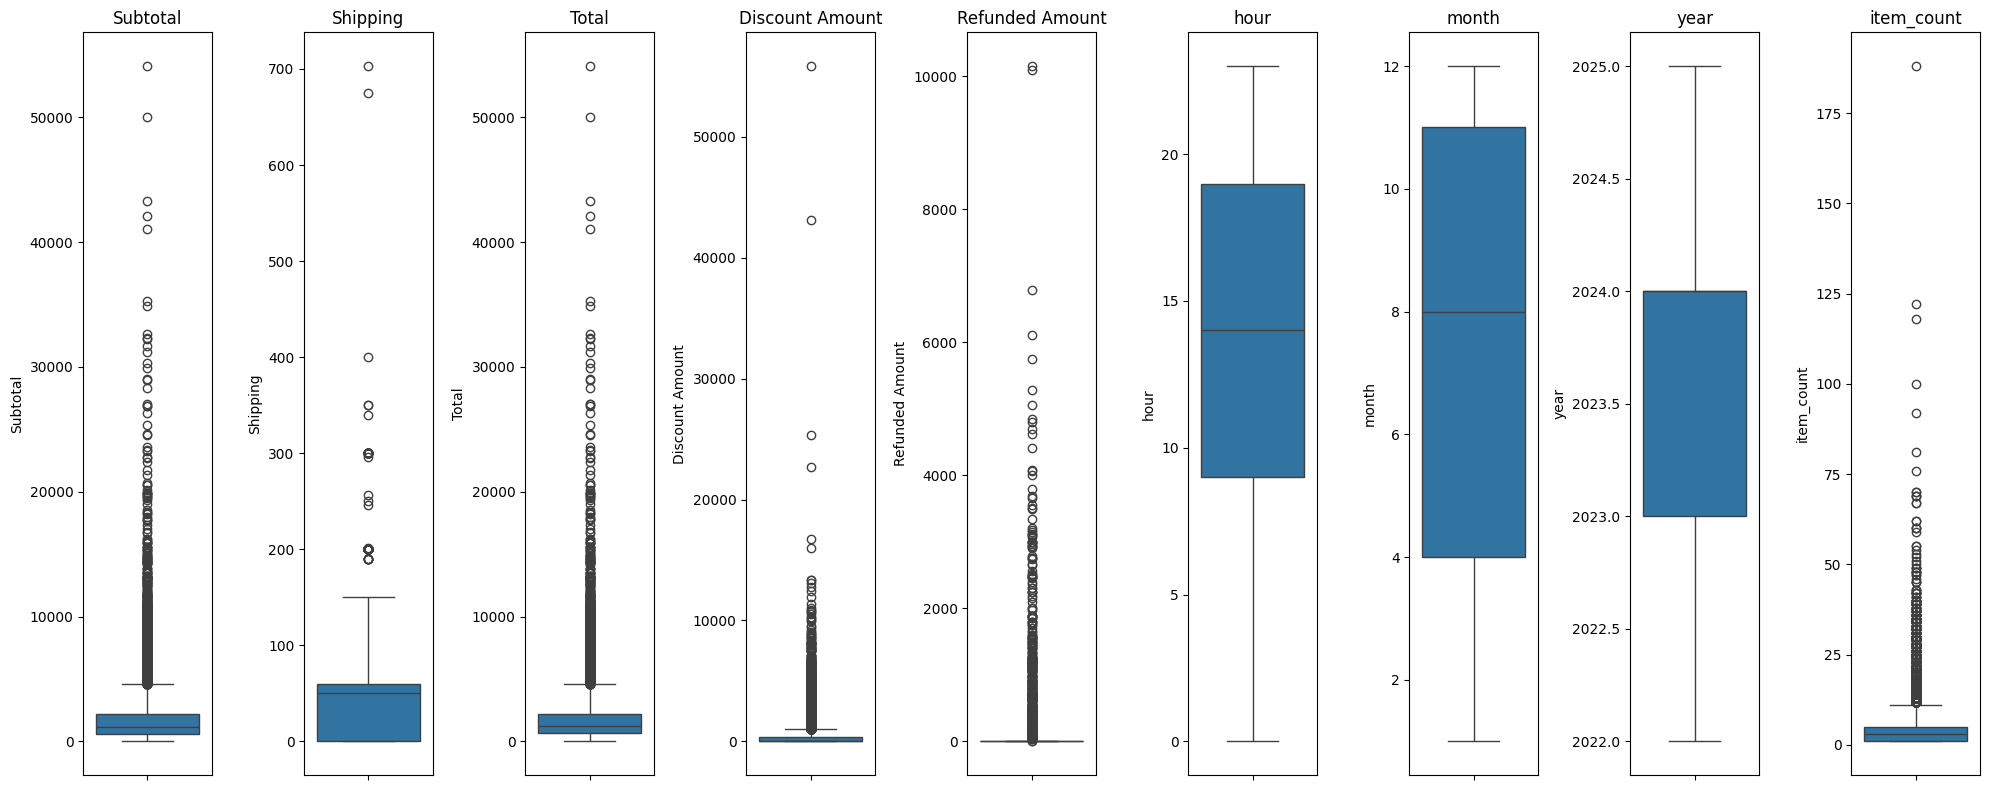

In [7]:
numerical_columns = df.select_dtypes(include=['float64', 'int64']).columns

plt.figure(figsize=(20, 8))

for i, column in enumerate(numerical_columns, 1):
    plt.subplot(1, len(numerical_columns), i) 
    sns.boxplot(y=df[column])
    plt.title(column)
    
plt.tight_layout()
plt.show()

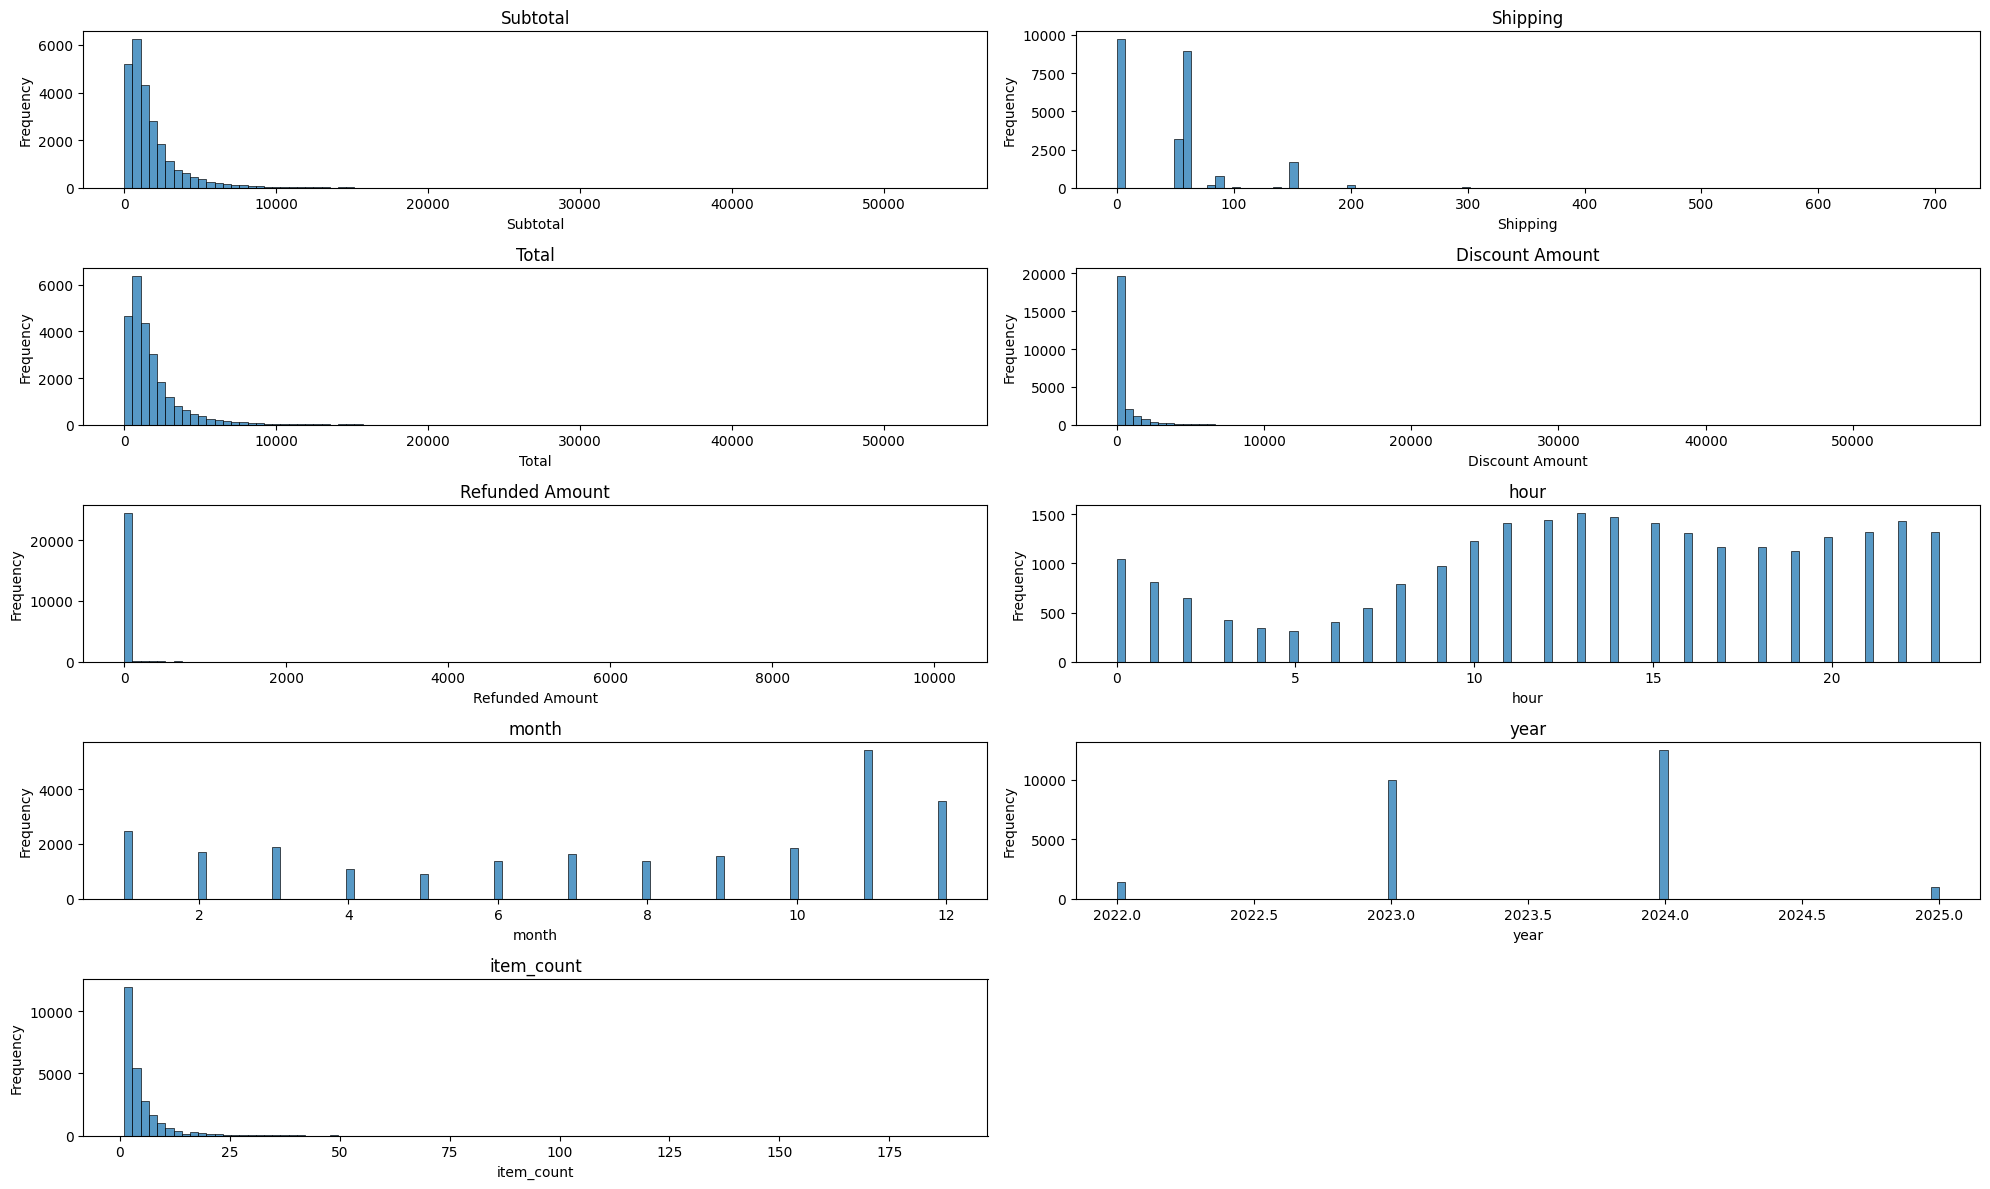

In [8]:
numerical_columns = df.select_dtypes(include=['float64', 'int64']).columns

plt.figure(figsize=(20, 12))

num_cols = len(numerical_columns)
num_rows = (num_cols + 1) // 2 

for i, column in enumerate(numerical_columns, 1):
    plt.subplot(num_rows, 2, i)  
    sns.histplot(x=df[column], bins=100)
    plt.title(column)
    plt.xlabel(column)
    plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

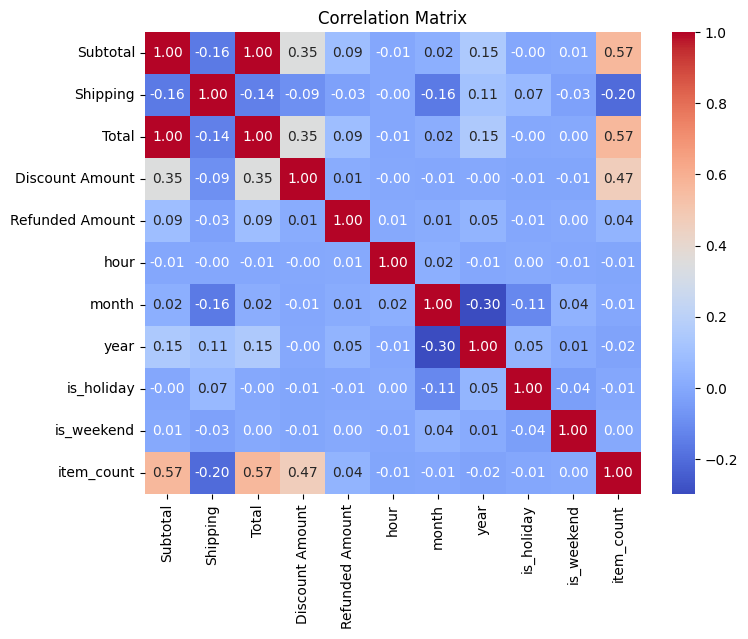

In [9]:
corr = df.corr(numeric_only=True)
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()

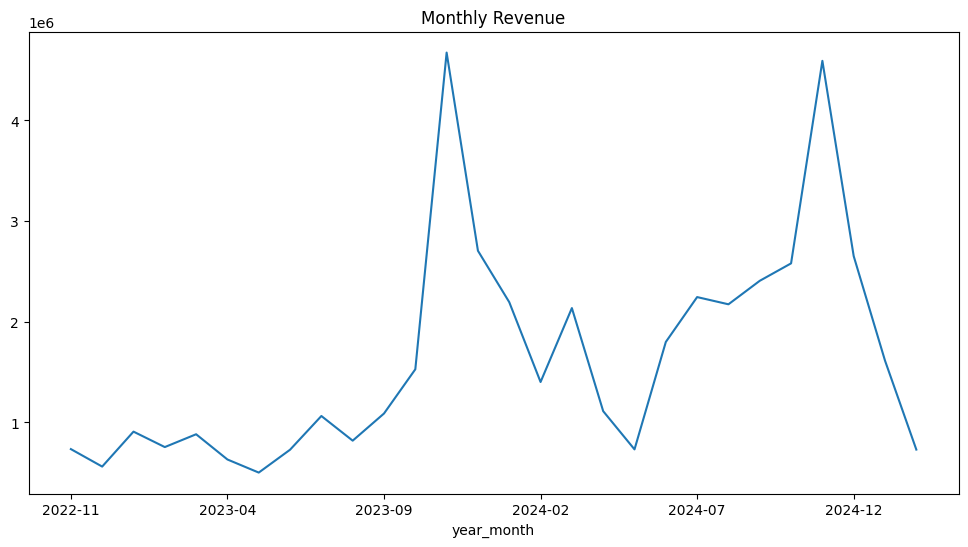

In [10]:
monthly_revenue = df.groupby('year_month')['Total'].sum()
monthly_revenue.plot(kind='line', figsize=(12, 6), title='Monthly Revenue')
plt.show()

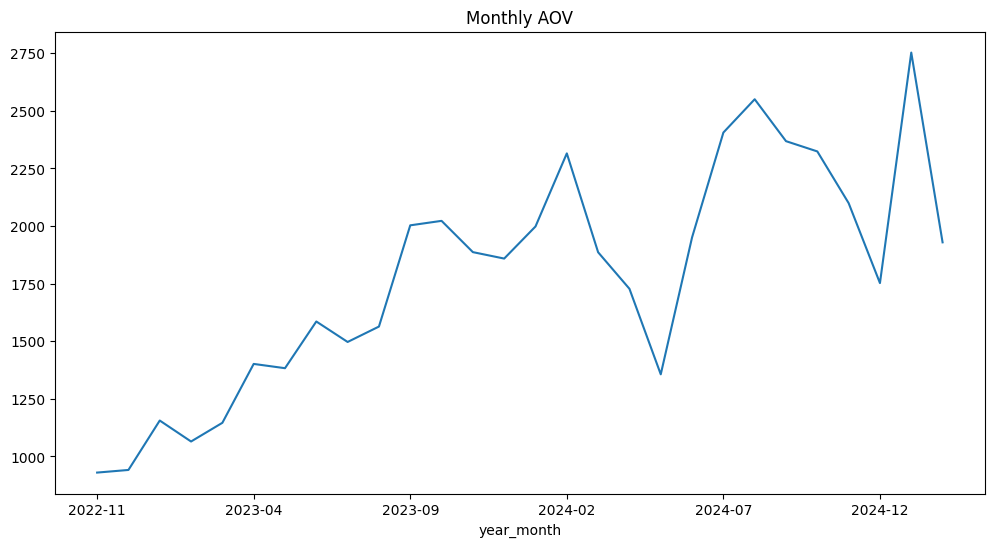

In [11]:
monthly_aov = df.groupby('year_month')['Total'].mean()
monthly_aov.plot(kind='line', figsize=(12, 6), title='Monthly AOV')
plt.show()

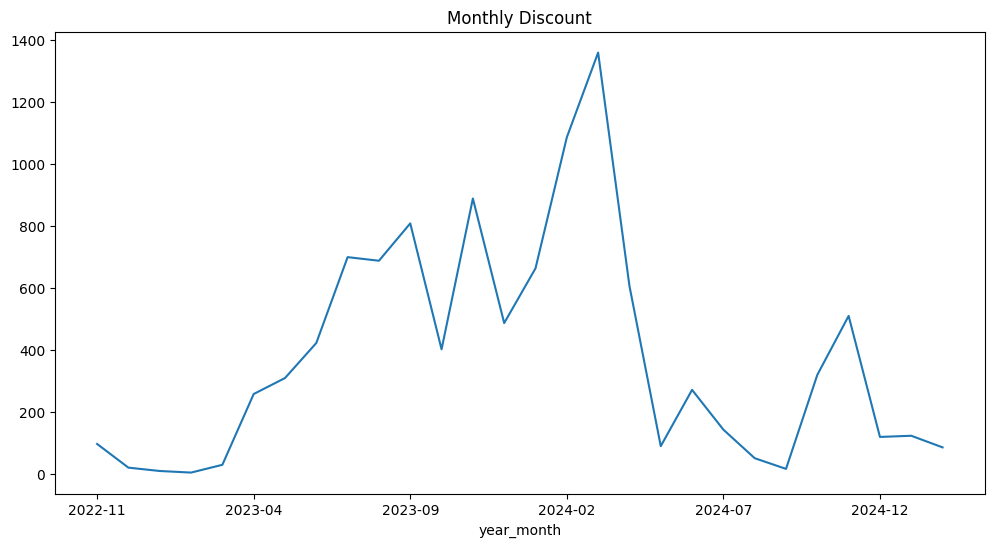

In [12]:
monthly_discount = df.groupby('year_month')['Discount Amount'].mean()
monthly_discount.plot(kind='line', figsize=(12, 6), title='Monthly Discount')
plt.show()

Lineitem name
["Chef's Kitchen Towel - Beige", "Chef's Kitchen Towel - Beige", "Chef's Kitchen Towel - Beige", "Chef's Kitchen Towel - Off White"]                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                        0.0
['Plain Bedsheet 100% Cotton - Burgundy', 'Classic Bath Mat 950GSM - Navy', 'Honeycomb Bath Mat 950GSM - Grey', 'Plain Bathrobe 500GSM - Grey / L', 'Plain Bathrobe 500GSM - Pink / M', 'Diamond Towel 550GSM - 50x100 / Dark Rose', 'Diamond Towel 550GSM - 90x150 / Dark Rose']                                                         

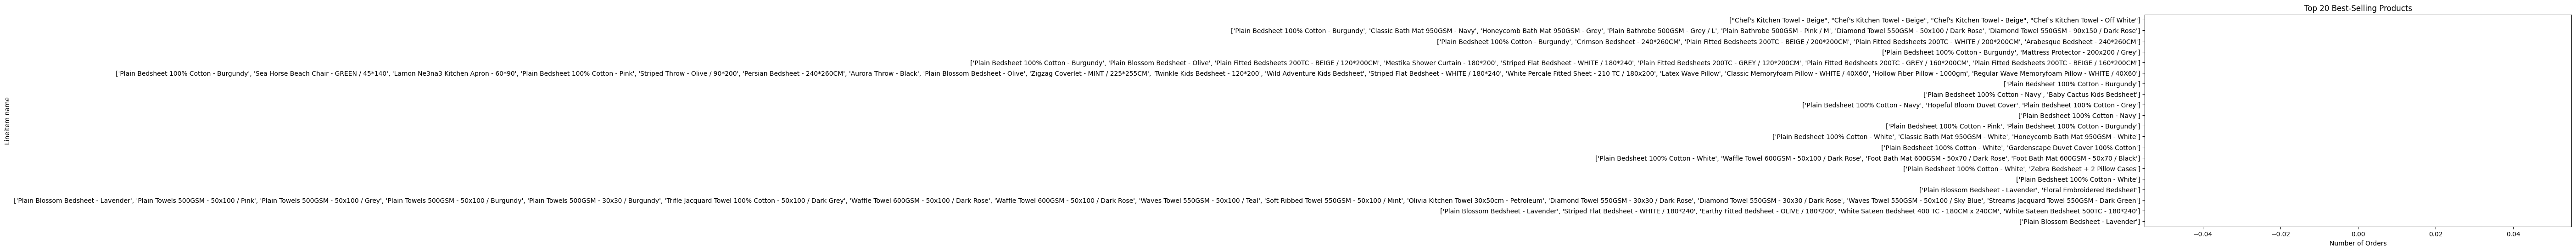

In [13]:
all_products = df['Lineitem name'].explode()
all_products = pd.concat([all_products,df['Lineitem quantity'].explode()],axis=1)
all_products['Lineitem quantity'] = pd.to_numeric(all_products['Lineitem quantity'], errors='coerce')

top_products = all_products.groupby('Lineitem name')['Lineitem quantity'].sum().sort_values(ascending=False).head(20)
    

plt.figure(figsize=(12,6))
sns.barplot(x=top_products.values, y=top_products.index)
plt.title('Top 20 Best-Selling Products')
plt.xlabel('Number of Orders')
top_products

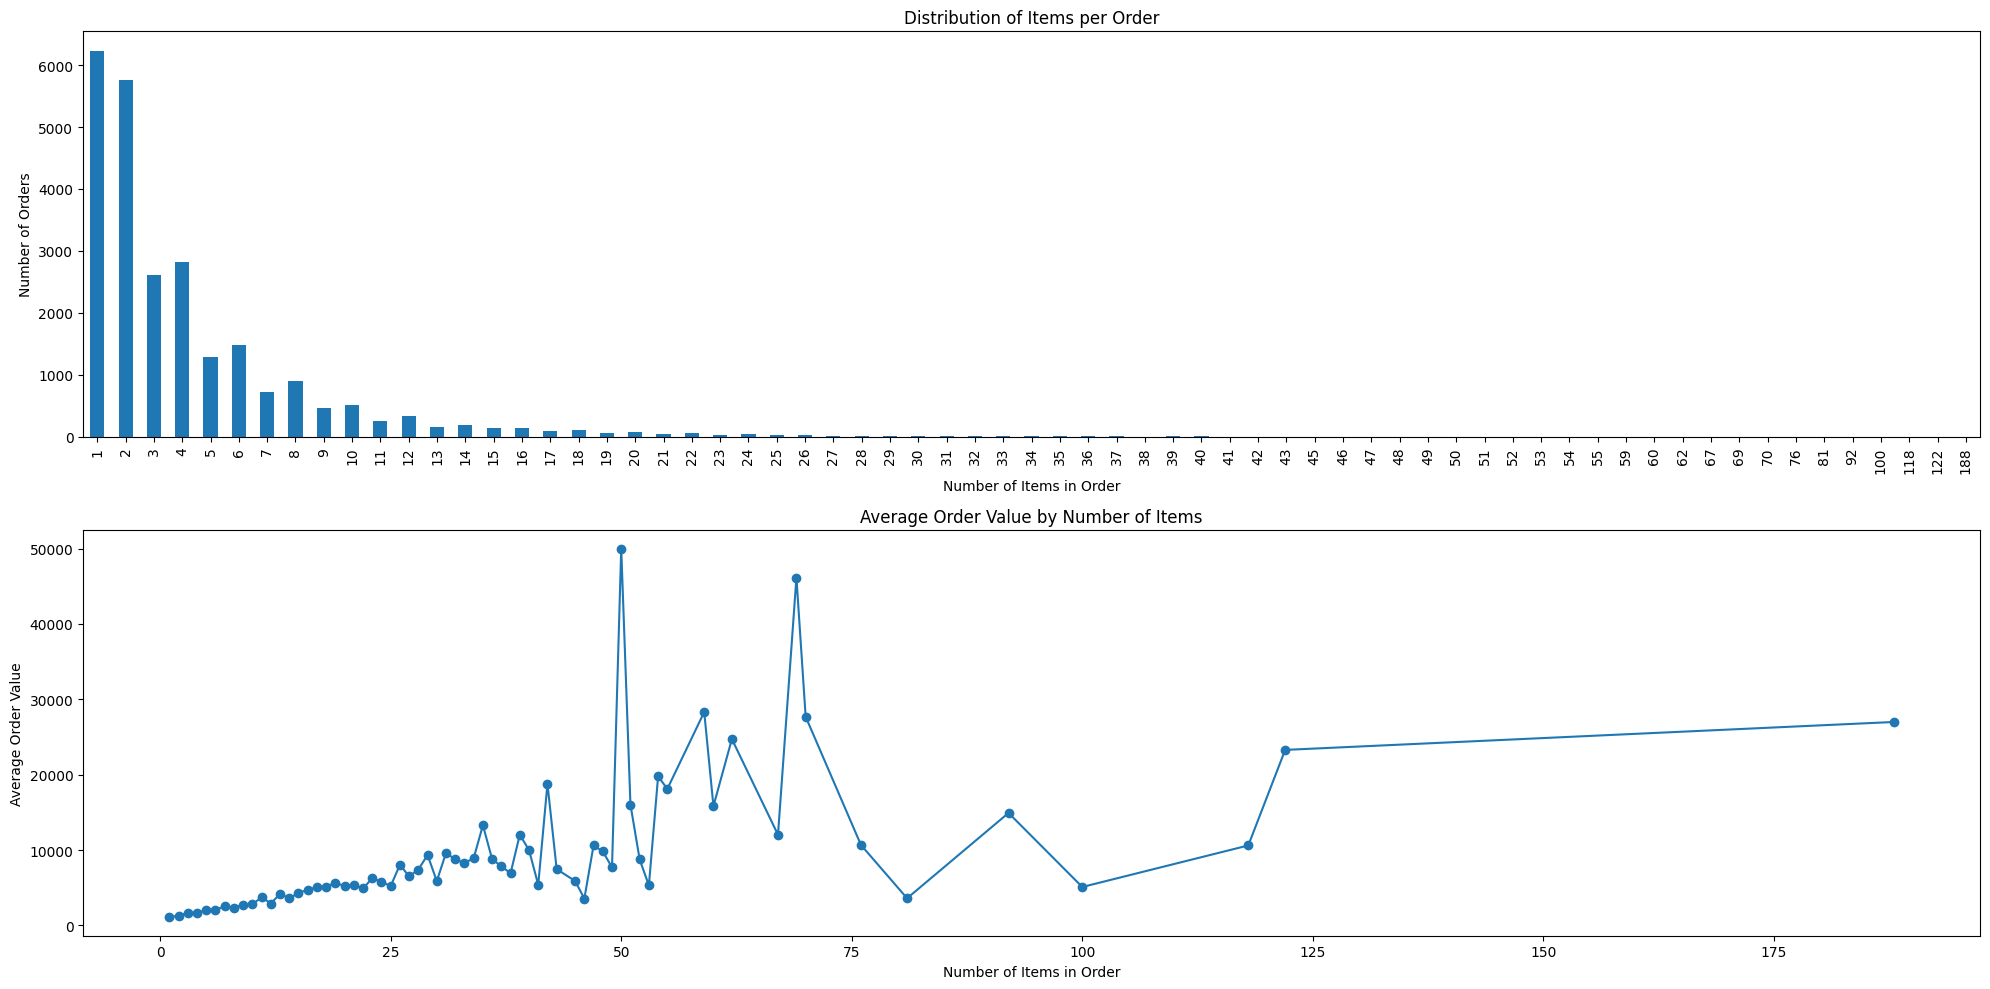

In [14]:
plt.figure(figsize=(20, 10))
# Distribution of order sizes
plt.subplot(2, 1, 1)
df['item_count'].value_counts().sort_index().plot(kind='bar')
plt.title('Distribution of Items per Order')
plt.xlabel('Number of Items in Order')
plt.ylabel('Number of Orders')

# Average order value by number of items
plt.subplot(2, 1, 2)
avg_order_value = df.groupby('item_count')['Total'].mean()
avg_order_value.plot(kind='line', marker='o')
plt.title('Average Order Value by Number of Items')
plt.xlabel('Number of Items in Order')
plt.ylabel('Average Order Value')

plt.tight_layout()
plt.show()




In [15]:
day_analysis = df.groupby('day_type').agg({
    'Total': ['count', 'mean', 'sum'],
    'item_count': ['sum'] 
}).round(2)

day_analysis.columns = ['count', 'mean', 'sum', 'items_count']

day_analysis = day_analysis.reindex(['Holiday', 'Weekday', 'Weekend'])


In [16]:

yearly_orders = df.groupby('year').agg({
    'Name': 'count',
    'Total': 'sum'
}).rename(columns={'Name': 'order_count'})

seasonal_analysis = df.groupby('season',observed=False).agg({
    'Name': 'count',
    'Total': ['mean', 'sum'],
})
seasonal_orders = df.groupby(['year', 'season'],observed=False)['Total'].sum().unstack()


monthly_trend = df.groupby('year_month').agg({
    'Name': 'count',
    'Total': 'sum'
})

province_yearly = df.groupby(['year', 'Shipping Province Name']).agg({
    'Name': 'count',
    'Total': 'sum'
})

pivot_province = province_yearly.reset_index().pivot(
    index='Shipping Province Name', 
    columns='year', 
    values='Total'
)



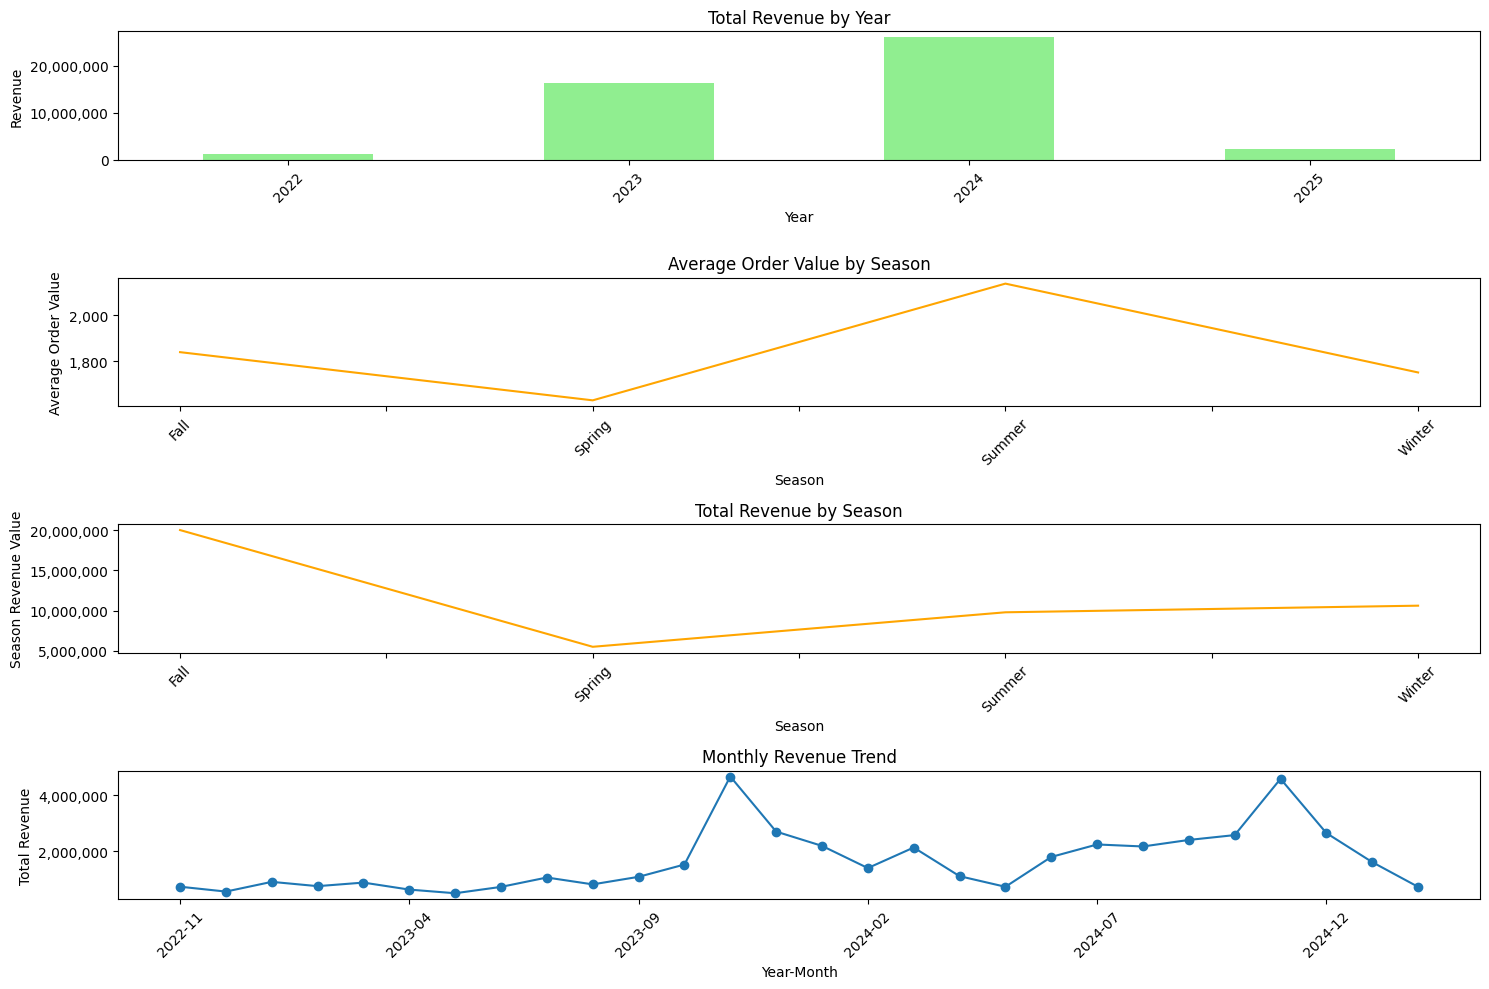

In [17]:
plt.figure(figsize=(15, 10))

# Yearly revenue subplot
plt.subplot(4, 1, 1)
ax1 = yearly_orders['Total'].plot(kind='bar', y='Total', color='lightgreen')
plt.title('Total Revenue by Year')
plt.xlabel('Year')
plt.ylabel('Revenue')
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: format(int(x), ',')))
plt.xticks(rotation=45)

#  Seasonal Analysis
plt.subplot(4, 1, 2)
ax2 = seasonal_analysis['Total']['mean'].plot(kind='line',y='mean', color='orange')
plt.title('Average Order Value by Season')
plt.xlabel('Season')
plt.ylabel('Average Order Value')
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: format(int(x), ',')))
plt.xticks(rotation=45)

#  Seasonal Analysis
plt.subplot(4, 1, 3)
ax3 = seasonal_analysis['Total']['sum'].plot(kind='line',y='sum', color='orange')
plt.title('Total Revenue by Season')
plt.xlabel('Season')
plt.ylabel('Season Revenue Value')
ax3.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: format(int(x), ',')))
plt.xticks(rotation=45)

#  Monthly Trend
plt.subplot(4,1, 4)
ax4 = monthly_trend['Total'].plot(kind='line', marker='o')
plt.title('Monthly Revenue Trend')
plt.xlabel('Year-Month')
plt.ylabel('Total Revenue')
ax4.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: format(int(x), ',')))
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()



<Figure size 1500x1000 with 0 Axes>

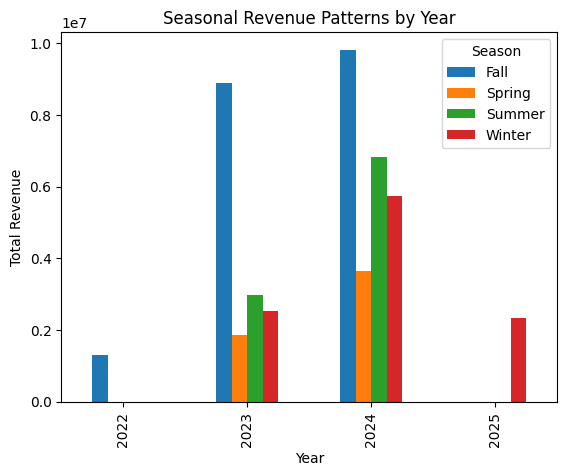

In [18]:
plt.figure(figsize=(15,10))


seasonal_orders.plot(kind='bar')
plt.title('Seasonal Revenue Patterns by Year')
plt.xlabel('Year')
plt.ylabel('Total Revenue')
plt.legend(title='Season')

plt.show()

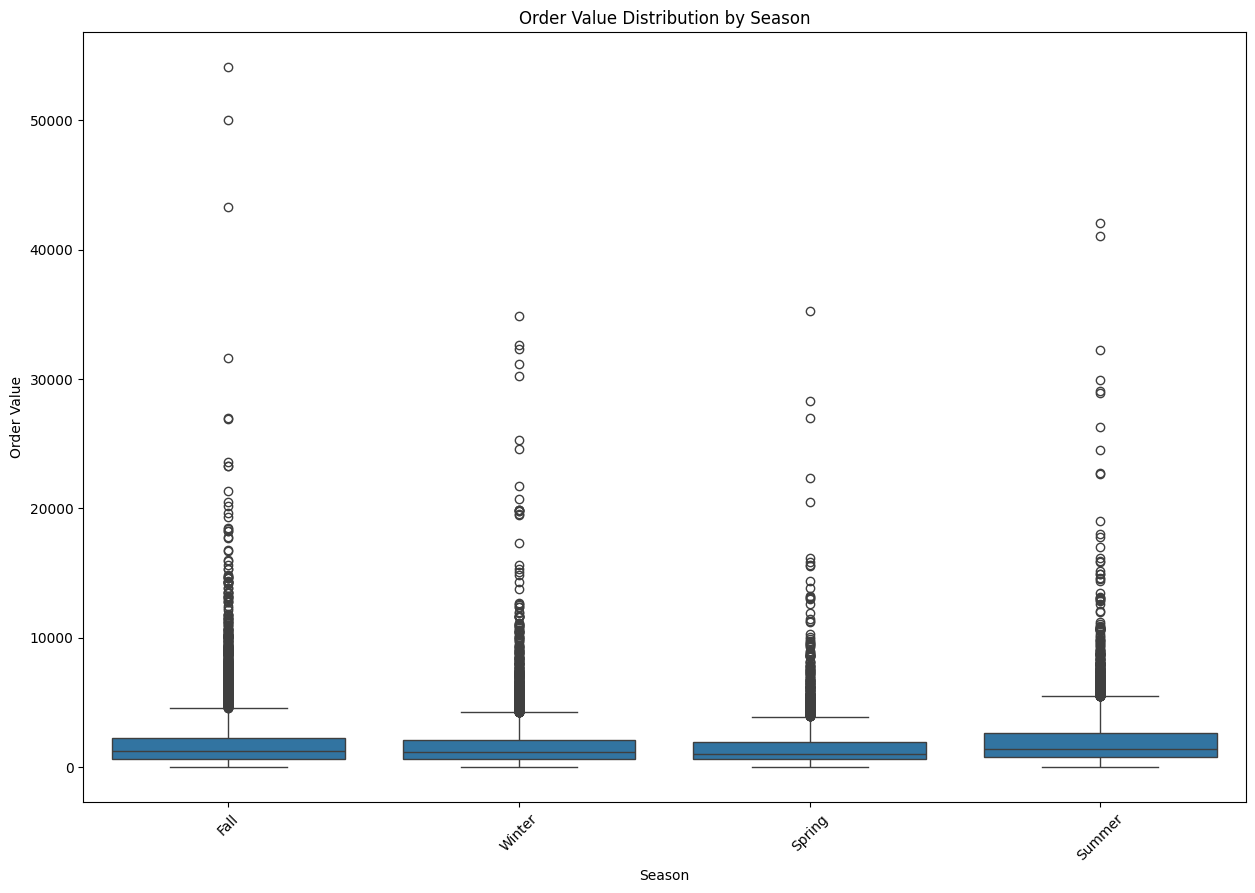

In [19]:
plt.figure(figsize=(15, 10))
sns.boxplot(data=df, x='season', y='Total')
plt.title('Order Value Distribution by Season')
plt.xlabel('Season')
plt.ylabel('Order Value')
plt.xticks(rotation=45)

plt.show()

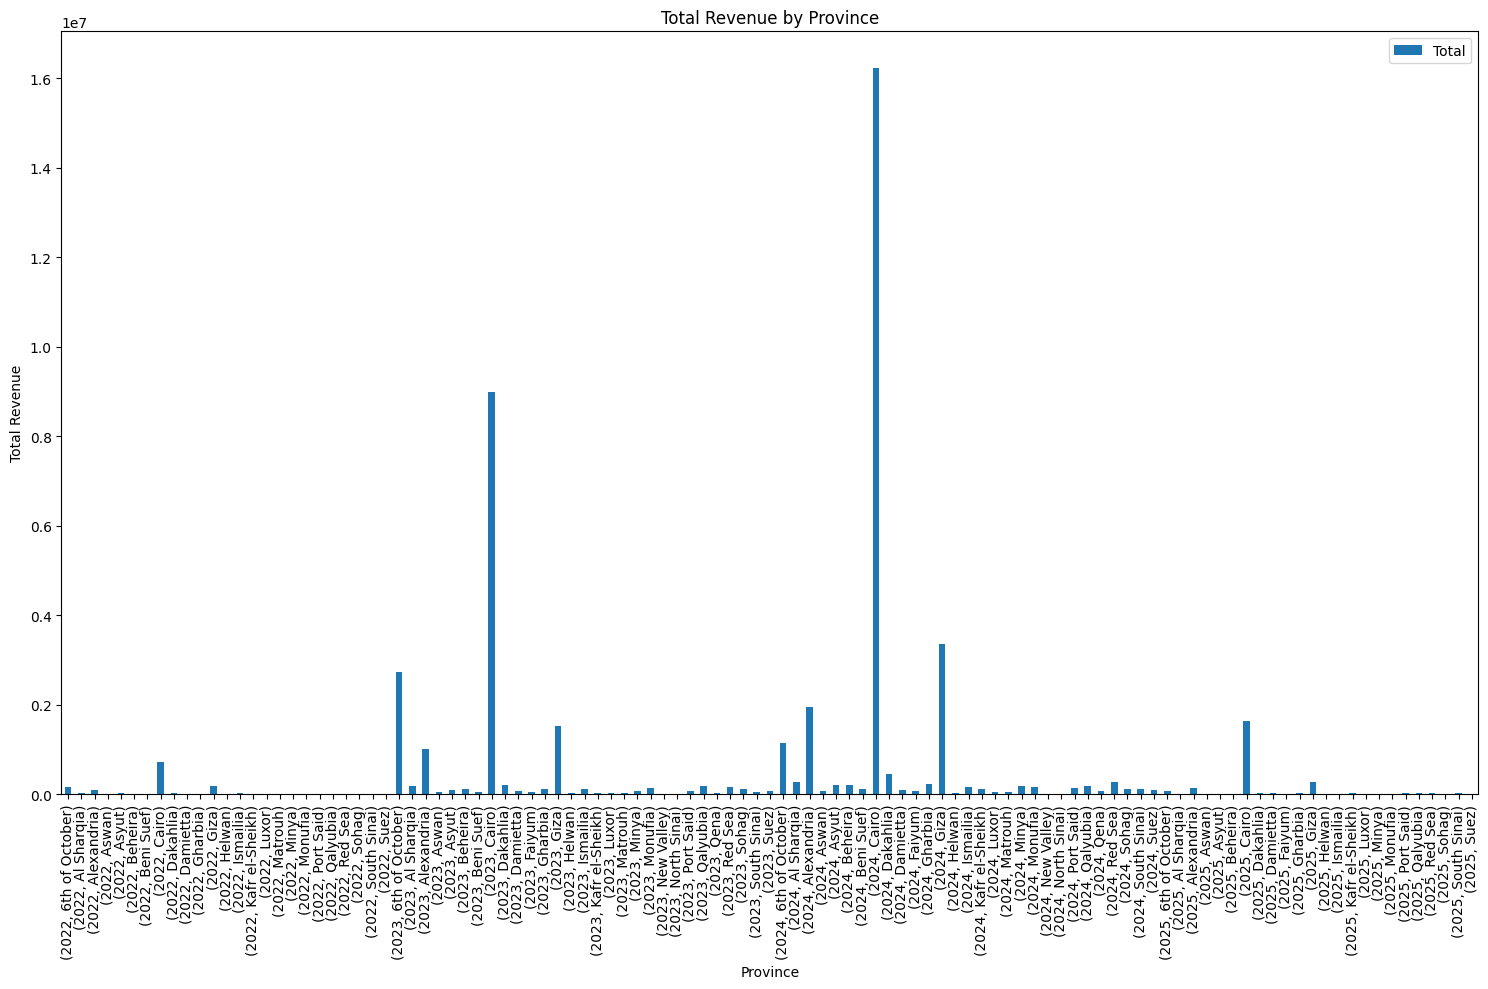

In [20]:
province_yearly.plot(kind='bar', y='Total', figsize=(15, 10))
plt.title('Total Revenue by Province')
plt.xlabel('Province')
plt.ylabel('Total Revenue')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

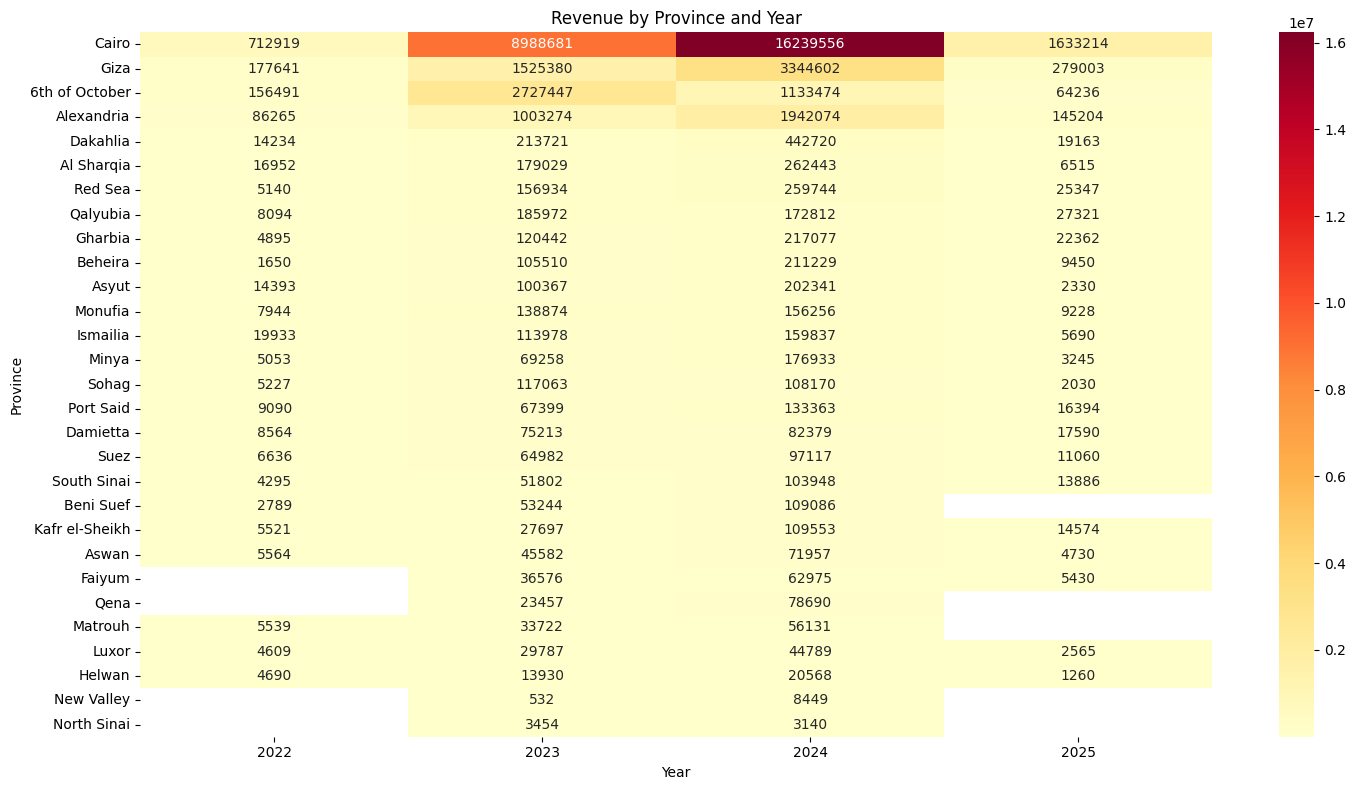

In [21]:

plt.figure(figsize=(15, 8))
province_totals = pivot_province.sum(axis=1).sort_values(ascending=False)
pivot_province_sorted = pivot_province.reindex(province_totals.index)
sns.heatmap(pivot_province_sorted, annot=True, fmt='.0f', cmap='YlOrRd')
plt.title('Revenue by Province and Year')
plt.xlabel('Year')
plt.ylabel('Province')
plt.tight_layout()
plt.show()


In [23]:
yoy_growth = ((yearly_orders - yearly_orders.shift(1)) / yearly_orders.shift(1)) * 100

mom_growth = ((monthly_trend - monthly_trend.shift(1)) / monthly_trend.shift(1)) * 100



product_prices = []
for idx, row in df.iterrows():
    row['Created at'] = pd.to_datetime(row['Created at'])
    year = row['Created at'].year
    for price, product in zip(row['Lineitem price'], row['Lineitem name']):
        product_prices.append({
            'year': year,
            'product': product,
            'price': price
        })

product_df = pd.DataFrame(product_prices)

# Convert the 'price' column to numeric, forcing errors to NaN
product_df['price'] = pd.to_numeric(product_df['price'], errors='coerce')

yearly_prices = product_df.groupby(['year', 'product'])['price'].mean().reset_index()

price_pivot = yearly_prices.pivot(index='product', columns='year', values='price')

yoy_changes = pd.DataFrame()
for year in range(price_pivot.columns.min()+1, price_pivot.columns.max()+1):
    
    yoy = ((price_pivot[year] - price_pivot[year-1]) / price_pivot[year-1] * 100)

    yoy = yoy.replace([np.inf, -np.inf], np.nan)
    yoy_changes[f'{year}_YoY%'] = yoy

final_analysis = pd.concat([price_pivot, yoy_changes], axis=1)

final_analysis = final_analysis.sort_index()






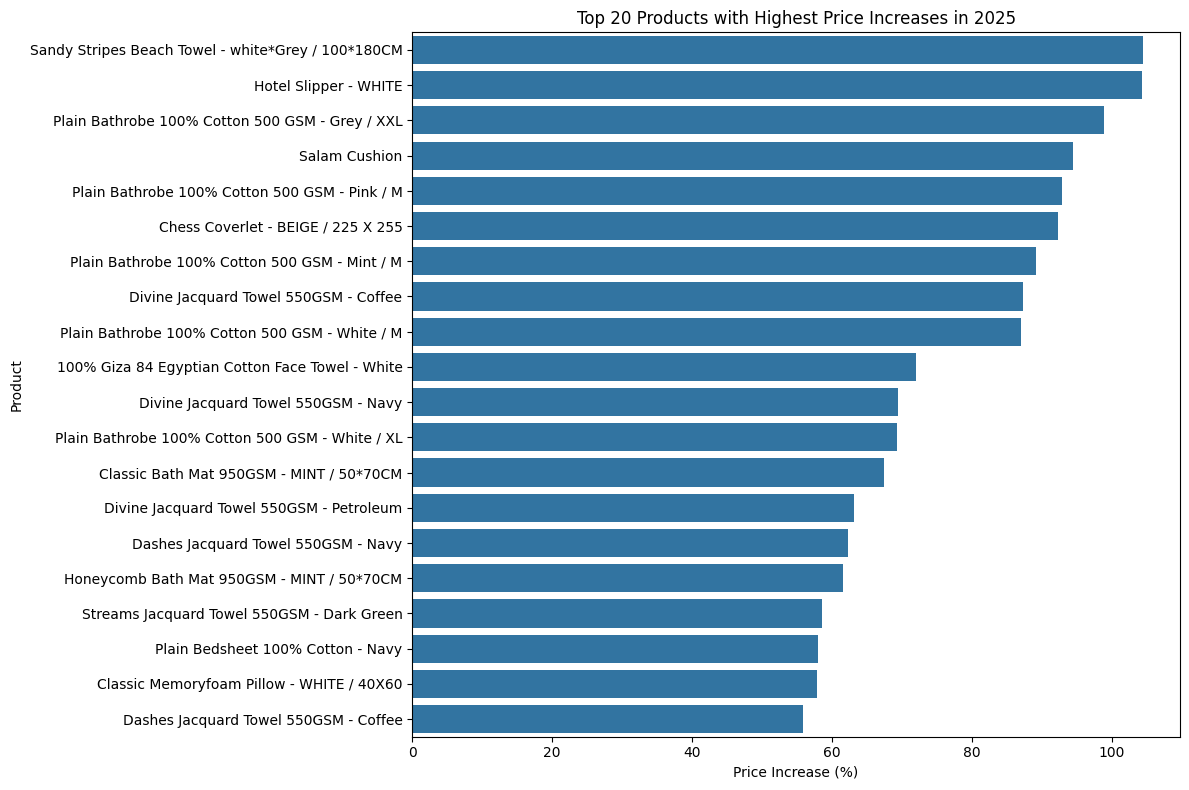

In [ ]:
plt.figure(figsize=(12,8))

latest_year = f'{price_pivot.columns.max()}_YoY%'
top_20_increases = yoy_changes[latest_year].sort_values(ascending=False).head(20)

sns.barplot(x=top_20_increases.values, y=top_20_increases.index)
plt.title(f'Top 20 Products with Highest Price Increases in {price_pivot.columns.max()}')
plt.xlabel('Price Increase (%)')
plt.ylabel('Product')
plt.tight_layout()
plt.show()

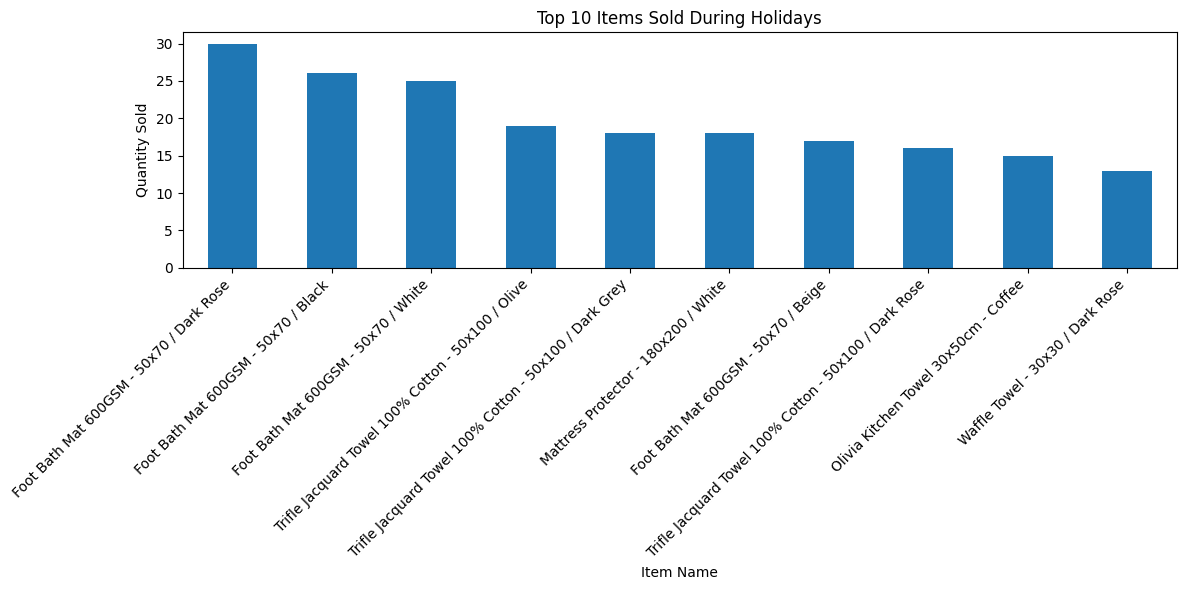

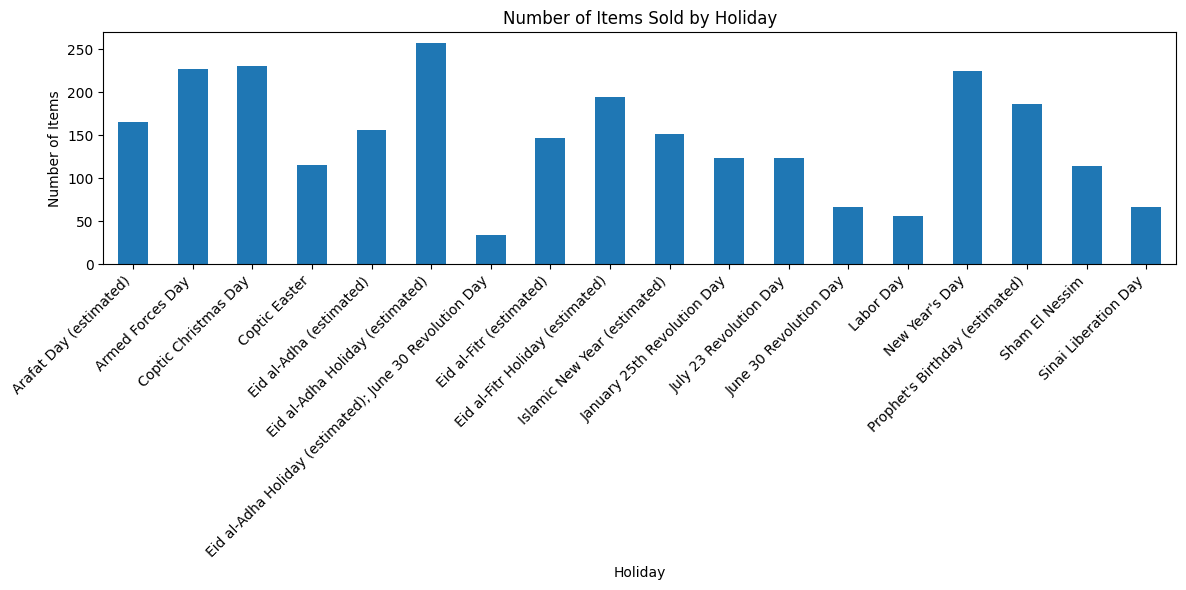

In [ ]:
if df['is_holiday'].any():
    holiday_items = []
    
    # Process each holiday order
    holiday_orders = df[df['is_holiday']]
    for _, row in holiday_orders.iterrows():
        items = row['Lineitem name']
        prices = row['Lineitem price']
        holiday = row['holiday_name']

        for item, price in zip(items, prices):
            holiday_items.append({
                'holiday': holiday,
                'item': item.strip(),
                'price': float(price),
                'date': row['Created at']
            })
    
    holiday_items_df = pd.DataFrame(holiday_items)
    

    holiday_analysis = holiday_items_df.groupby(['holiday', 'item']).agg({
        'item': 'count',
        'price': ['mean', 'sum']
    }).round(2)
    
    holiday_analysis.columns = ['quantity_sold', 'avg_price', 'total_revenue']
    

    
    # Top items sold during holidays
    top_holiday_items = holiday_items_df.groupby('item')['item'].count().sort_values(ascending=False).head(10)
    
    plt.figure(figsize=(12, 6))
    top_holiday_items.plot(kind='bar')
    plt.title('Top 10 Items Sold During Holidays')
    plt.xlabel('Item Name')
    plt.ylabel('Quantity Sold')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
    
    # Sales distribution by holiday
    plt.figure(figsize=(12, 6))
    holiday_items_df.groupby('holiday')['item'].count().plot(kind='bar')
    plt.title('Number of Items Sold by Holiday')
    plt.xlabel('Holiday')
    plt.ylabel('Number of Items')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()


Text(0, 0.5, 'Frequency')

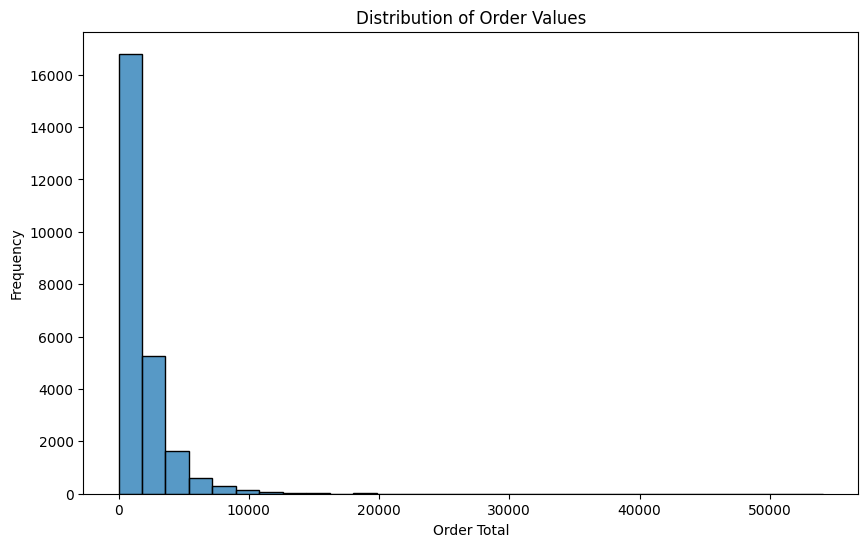

In [ ]:
plt.figure(figsize=(10,6))
sns.histplot(df['Subtotal'], bins=30)
plt.title('Distribution of Order Values')
plt.xlabel('Order Total')
plt.ylabel('Frequency')

## Statistics

In [34]:
# Summary statistics
print("\nOrder Size Summary:")
print(f"Most common order size: {df['item_count'].mode().values[0]} items")
print(f"Average order size: {df['item_count'].mean():.2f} items")
print(f"Maximum items in an order: {df['item_count'].max()}")
print(f"Minimum items in an order: {df['item_count'].min()}")



Order Size Summary:
Most common order size: 1 items
Average order size: 4.46 items
Maximum items in an order: 188
Minimum items in an order: 1


In [35]:
print("\nSales Analysis by Day Type:")
print(day_analysis)


print("\nItem Analysis:")
print(f"Average items per order: {df['item_count'].mean():.2f}")
print(f"Maximum items in an order: {df['item_count'].max()}")
print(f"Minimum items in an order: {df['item_count'].min()}")


Sales Analysis by Day Type:
          count     mean          sum  items_count
day_type                                          
Holiday     843  1804.65   1521319.14         3610
Weekday   16767  1837.97  30817317.49        74802
Weekend    7284  1864.64  13582034.57        32669

Item Analysis:
Average items per order: 4.46
Maximum items in an order: 188
Minimum items in an order: 1


In [36]:
yoy_changes['Avg_Change'] = yoy_changes.abs().mean(axis=1)
print("\nOverall Price Change Statistics:")
for year in yoy_changes.columns:
    if year != 'Avg_Change':
        print(f"\nYear {year}:")
        print(f"Average Change: {yoy_changes[year].mean():.2f}%")
        print(f"Median Change: {yoy_changes[year].median():.2f}%")
        print(f"Max Increase: {yoy_changes[year].max():.2f}%")
        print(f"Max Decrease: {yoy_changes[year].min():.2f}%")



Overall Price Change Statistics:

Year 2023_YoY%:
Average Change: 274.04%
Median Change: -13.60%
Max Increase: 19620.00%
Max Decrease: -59.21%

Year 2024_YoY%:
Average Change: 13.47%
Median Change: 0.72%
Max Increase: 532.01%
Max Decrease: -72.03%

Year 2025_YoY%:
Average Change: -6.51%
Median Change: -7.54%
Max Increase: 400.00%
Max Decrease: -90.13%


In [37]:
print("\nSummary Statistics of Year-over-Year Price Changes:")
yoy_changes.describe()


Summary Statistics of Year-over-Year Price Changes:


,2023_YoY%,2024_YoY%,2025_YoY%,Avg_Change
count,69.000000,74.000000,69.000000,75.000000
mean,274.044052,13.472495,-6.513844,162.144704
std,2363.490579,67.790261,56.232214,1131.284139
min,-59.210526,-72.027972,-90.133607,2.754010
25%,-28.571429,-8.506364,-29.089323,11.812324
50%,-13.596234,0.717205,-7.537586,19.251600
75%,-0.730122,21.475013,4.910518,30.871664
max,19620.000000,532.014388,400.000000,9816.896552


## 2. Advanced EDA

#                                                           Advanced EDA

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from pandas.plotting import autocorrelation_plot
import scipy.stats as stats


### Load and Preprocess the Data

In [2]:
df = pd.read_csv("depi_grouped_main.csv", parse_dates=['Created at'])

df.head()

,Name,Created at,Subtotal,Shipping,Total,Discount Amount,Shipping Method,Shipping Province,Shipping Province Name,Payment Method,...,month,day_of_week,year,year_month,season,holiday_name,is_holiday,is_weekend,day_type,item_count
0,#MC14035,2022-11-01 00:32:29+02:00,1150.0,0.0,1150.0,95.0,Free Shipping,C,Cairo,Cash on Delivery (COD),...,11,Tuesday,2022,2022-11,Fall,NaN,False,False,Weekday,18
1,#MC14036,2022-11-01 04:58:48+02:00,620.0,50.0,670.0,0.0,Shipping Rate,C,Cairo,Cash on Delivery (COD),...,11,Tuesday,2022,2022-11,Fall,NaN,False,False,Weekday,3
2,#MC14037,2022-11-01 07:49:44+02:00,440.0,50.0,490.0,0.0,Shipping Rate,GZ,Giza,Cash on Delivery (COD),...,11,Tuesday,2022,2022-11,Fall,NaN,False,False,Weekday,1
3,#MC14038,2022-11-01 08:08:38+02:00,600.0,50.0,650.0,0.0,Shipping Rate,C,Cairo,Cash on Delivery (COD),...,11,Tuesday,2022,2022-11,Fall,NaN,False,False,Weekday,1
4,#MC14039,2022-11-01 08:21:14+02:00,408.0,50.0,458.0,0.0,Shipping Rate,C,Cairo,Cash on Delivery (COD),...,11,Tuesday,2022,2022-11,Fall,NaN,False,False,Weekday,6


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24856 entries, 0 to 24855
Data columns (total 29 columns):
 #   Column                     Non-Null Count  Dtype                    
---  ------                     --------------  -----                    
 0   Name                       24856 non-null  object                   
 1   Created at                 24856 non-null  datetime64[ns, UTC+02:00]
 2   Subtotal                   24856 non-null  float64                  
 3   Shipping                   24856 non-null  float64                  
 4   Total                      24856 non-null  float64                  
 5   Discount Amount            24856 non-null  float64                  
 6   Shipping Method            24856 non-null  object                   
 7   Shipping Province          24856 non-null  object                   
 8   Shipping Province Name     24856 non-null  object                   
 9   Payment Method             24856 non-null  object                   
 10

In [8]:
# df_daily = df.groupby('Created at').agg({
#     'Total': 'sum',
#     'item_count': 'sum'
# }).reset_index()


# date_range = pd.date_range(start=df_daily['Created at'].min(), end=df_daily['Created at'].max(), freq='D')

# df_daily = pd.merge(pd.DataFrame({'Created at': date_range}), df_daily, on='Created at', how='left')

# df_daily.fillna(method='ffill', inplace=True)

# df_daily.set_index('Created at', inplace=True)


df_daily = pd.read_csv("daily_sales_data.csv")

### Visualizing the Time Series and identifying trends

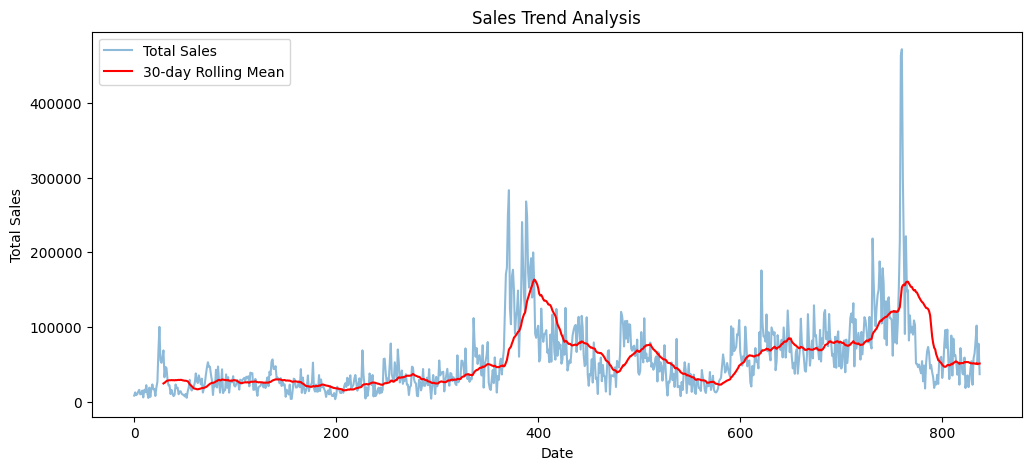

In [10]:
# df_daily['Rolling_Mean'] = df_daily['Total'].rolling(window=30).mean()

plt.figure(figsize=(12, 5))
plt.plot(df_daily['Total'], label="Total Sales", alpha=0.5)
plt.plot(df_daily['total_30d_avg'], label="30-day Rolling Mean", color='red')
plt.xlabel("Date")
plt.ylabel("Total Sales")
plt.title("Sales Trend Analysis")
plt.legend()
plt.show()


### Detecting Seasonality

<Axes: title={'center': 'Seasonal Component'}, xlabel='Created at'>

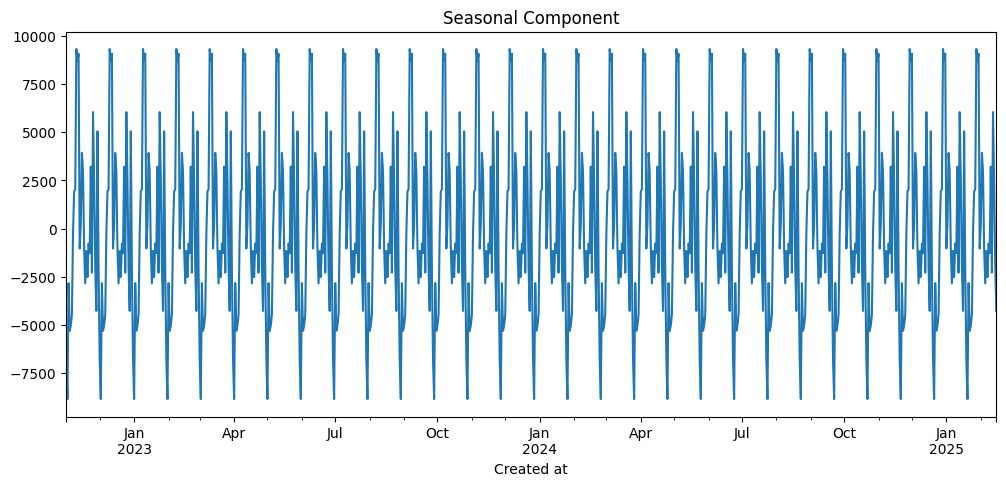

In [9]:
decomposition = seasonal_decompose(df_daily['Total'], model='additive', period=30)
decomposition.seasonal.plot(title="Seasonal Component", figsize=(12, 5))


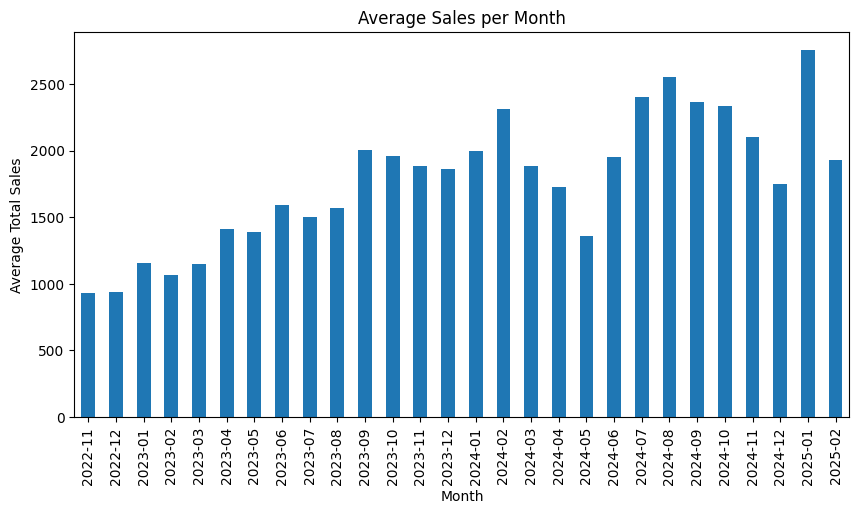

In [ ]:
df_monthly = df.groupby('year_month')['Total'].mean()

df_monthly.plot(kind='bar', figsize=(10, 5), title="Average Sales per Month")
plt.xlabel("Month")
plt.ylabel("Average Total Sales")
plt.show()


### Detecting Cyclic Patterns

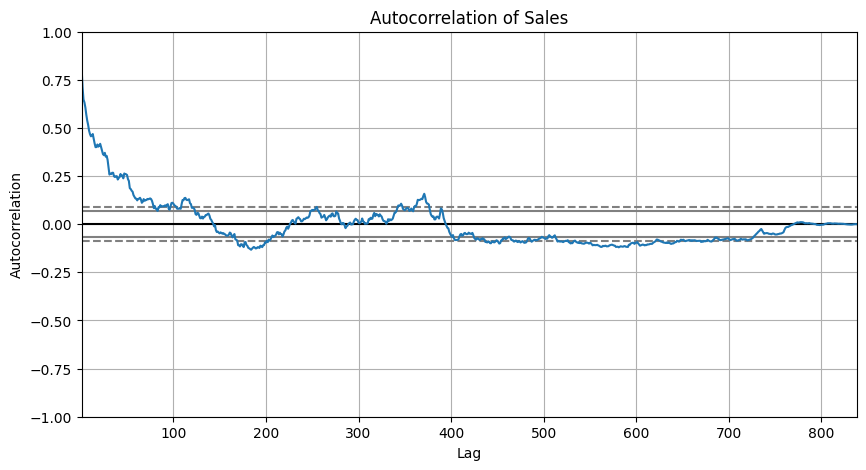

In [15]:
plt.figure(figsize=(10, 5))
autocorrelation_plot(df_daily['Total'])
plt.title("Autocorrelation of Sales")
plt.show()


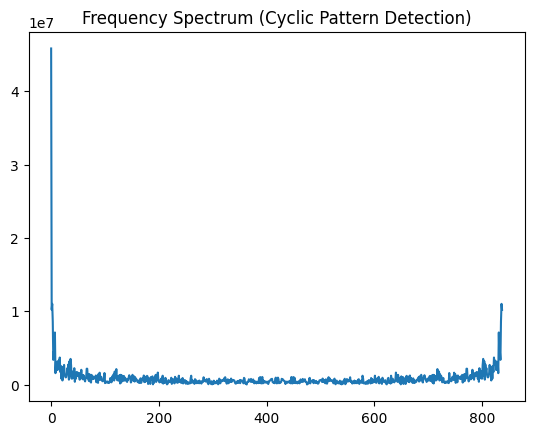

In [16]:
freq_spectrum = np.fft.fft(df_daily['Total'].dropna())
plt.plot(np.abs(freq_spectrum))
plt.title("Frequency Spectrum (Cyclic Pattern Detection)")
plt.show()


### Checking for Stationarity

In [17]:
result = adfuller(df_daily['Total'].dropna())

print("ADF Statistic:", result[0])
print("p-value:", result[1])
if result[1] < 0.05:
    print("The series is stationary (no trend).")
else:
    print("The series is non-stationary (trend present).")


ADF Statistic: -5.043686897997726
p-value: 1.81740943990513e-05
The series is stationary (no trend).


### Extras

In [18]:
df['is_holiday'] = df['is_holiday'].astype(int)
df['is_weekend'] = df['is_weekend'].astype(int)
df['season'] = df['season'].astype('category').cat.codes
df['day_of_week'] = df['day_of_week'].astype('category').cat.codes

numeric_cols = ['Total', 'Discount Amount', 'Refunded Amount', 'is_holiday',
                'is_weekend', 'item_count', 'season', 'day_of_week']

df_corr = df[numeric_cols]


In [19]:
corr_matrix = df_corr.corr(method='pearson')
print(corr_matrix)


                    Total  Discount Amount  Refunded Amount  is_holiday  \
Total            1.000000         0.352583         0.092005   -0.003448   
Discount Amount  0.352583         1.000000         0.012199   -0.014003   
Refunded Amount  0.092005         0.012199         1.000000   -0.005191   
is_holiday      -0.003448        -0.014003        -0.005191    1.000000   
is_weekend       0.003489        -0.010210         0.002143   -0.038121   
item_count       0.565015         0.466848         0.042086   -0.006301   
season           0.004896         0.005451        -0.013922    0.045613   
day_of_week     -0.004928         0.006716        -0.008282    0.005324   

                 is_weekend  item_count    season  day_of_week  
Total              0.003489    0.565015  0.004896    -0.004928  
Discount Amount   -0.010210    0.466848  0.005451     0.006716  
Refunded Amount    0.002143    0.042086 -0.013922    -0.008282  
is_holiday        -0.038121   -0.006301  0.045613     0.005324  

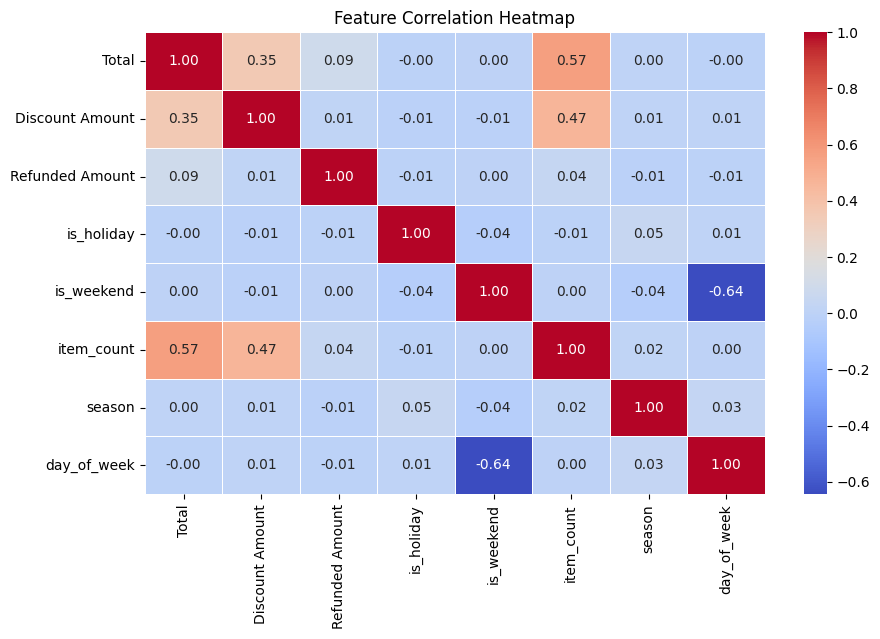

In [20]:
plt.figure(figsize=(10, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Feature Correlation Heatmap")
plt.show()


/var/folders/rd/rm1ghq0950j6l712s6ykcc5w0000gn/T/ipykernel_76120/3227513424.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df['season'], y=df['Total'], palette="coolwarm")


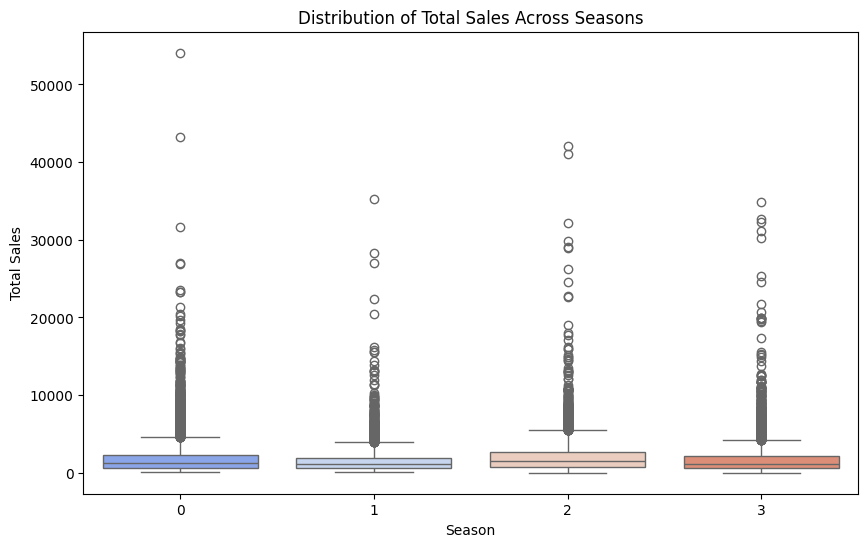

In [21]:
df['season'] = df['season'].astype('category')
plt.figure(figsize=(10,6))
sns.boxplot(x=df['season'], y=df['Total'], palette="coolwarm")
plt.title("Distribution of Total Sales Across Seasons")
plt.xlabel("Season")
plt.ylabel("Total Sales")
plt.show()


In [23]:
season_groups = [group['Total'].values for _, group in df.groupby('season',observed=False)]

f_stat, p_value = stats.f_oneway(*season_groups)

print(f"ANOVA F-statistic: {f_stat}")
print(f"P-value: {p_value}")
if p_value < 0.05:
    print("There is a significant difference in Total Sales across seasons.")
else:
    print("No significant difference in Total Sales across seasons.")


ANOVA F-statistic: 44.994678693828426
P-value: 5.457639638876034e-29
There is a significant difference in Total Sales across seasons.


In [24]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd
tukey_results = pairwise_tukeyhsd(df['Total'], df['season'])

print(tukey_results)


  Multiple Comparison of Means - Tukey HSD, FWER=0.05   
group1 group2  meandiff p-adj    lower    upper   reject
--------------------------------------------------------
     0      1 -204.3789    0.0 -312.0869  -96.671   True
     0      2  305.8626    0.0  209.5543 402.1709   True
     0      3  -84.8565 0.0614 -172.3868   2.6738  False
     1      2  510.2415    0.0  386.1818 634.3013   True
     1      3  119.5225 0.0441    2.1466 236.8983   True
     2      3 -390.7191    0.0 -497.7302 -283.708   True
--------------------------------------------------------


In [25]:
# Retrieve the original category order
category_mapping = dict(enumerate(df['season'].astype('category').cat.categories))
print(category_mapping)  # This shows which number corresponds to each season


{0: 0, 1: 1, 2: 2, 3: 3}


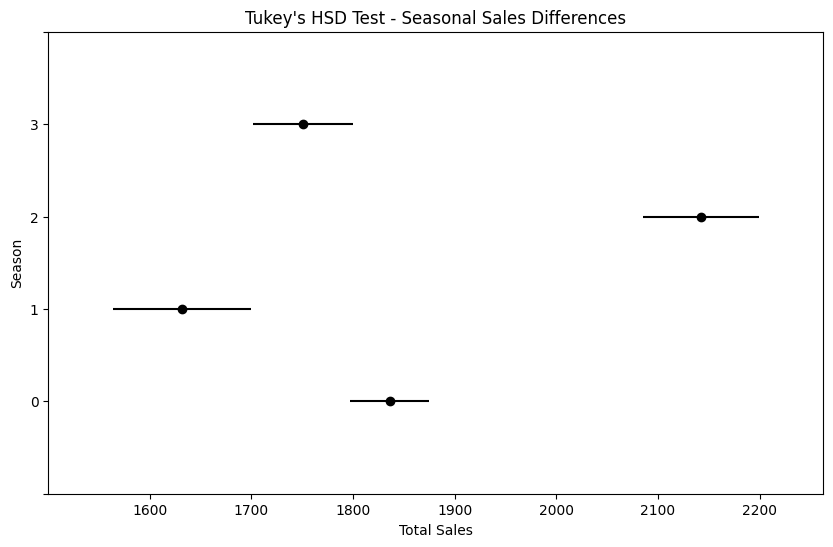

In [26]:
df['season'] = df['season'].map(category_mapping)
tukey_results.plot_simultaneous()
plt.xlabel("Total Sales")
plt.ylabel("Season")
plt.title("Tukey's HSD Test - Seasonal Sales Differences")
plt.show()

<Axes: xlabel='Total', ylabel='Density'>

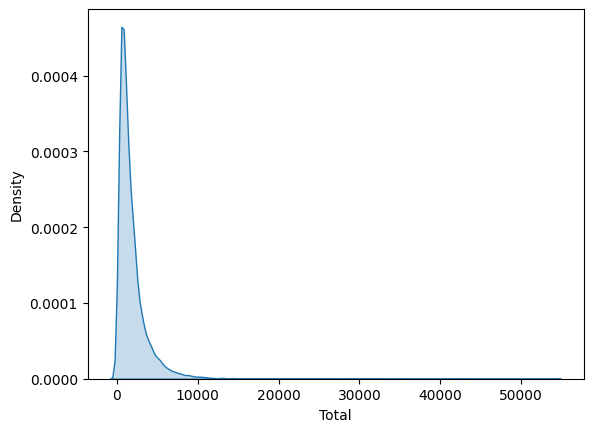

In [27]:
sns.kdeplot(df["Total"], fill=True)


#  Interactive Time Series Plot for dyanmaic Expolration

In [28]:
import plotly.express as px
fig = px.line(df, x="Created at", y="Total", title="Interactive Time Series Analysis")
fig.show()


/Users/ziadghanem/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning:

urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020



In [29]:
df['year'] = df['Created at'].dt.year
df['month'] = df['Created at'].dt.month
df['week_of_year'] = df['Created at'].dt.isocalendar().week
df['day_of_week'] = df['Created at'].dt.dayofweek
df['is_weekend'] = df['day_of_week'].apply(lambda x: 1 if x >= 5 else 0)

print(df.head())


       Name                Created at  Subtotal  Shipping   Total  \
0  #MC14035 2022-11-01 00:32:29+02:00    1150.0       0.0  1150.0   
1  #MC14036 2022-11-01 04:58:48+02:00     620.0      50.0   670.0   
2  #MC14037 2022-11-01 07:49:44+02:00     440.0      50.0   490.0   
3  #MC14038 2022-11-01 08:08:38+02:00     600.0      50.0   650.0   
4  #MC14039 2022-11-01 08:21:14+02:00     408.0      50.0   458.0   

   Discount Amount Shipping Method Shipping Province Shipping Province Name  \
0             95.0   Free Shipping                 C                  Cairo   
1              0.0   Shipping Rate                 C                  Cairo   
2              0.0   Shipping Rate                GZ                   Giza   
3              0.0   Shipping Rate                 C                  Cairo   
4              0.0   Shipping Rate                 C                  Cairo   

           Payment Method  ... day_of_week  year year_month season  \
0  Cash on Delivery (COD)  ...          

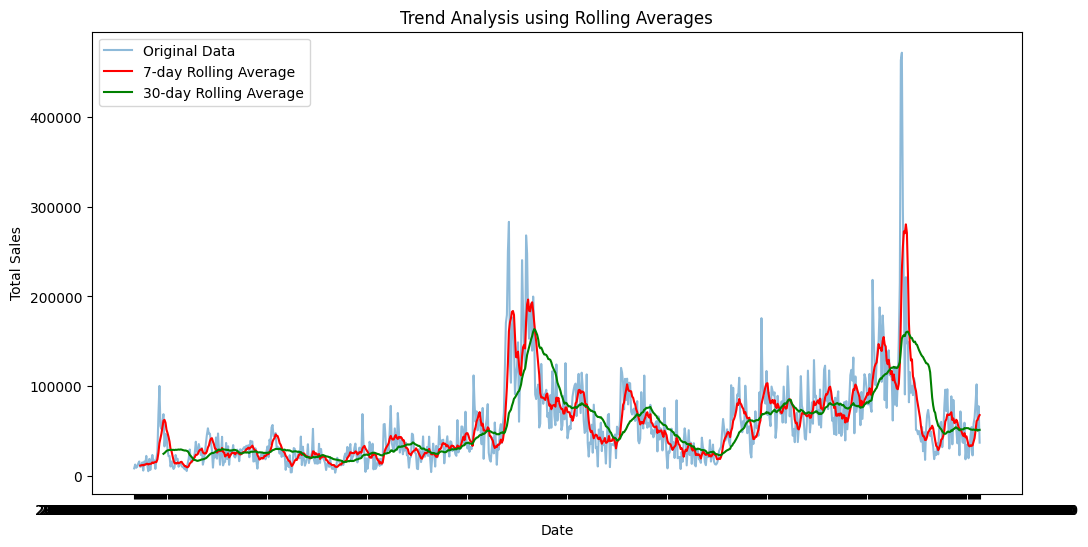

In [33]:
# df['rolling_7'] = df['Total'].rolling(window=7).mean()
# df['rolling_30'] = df['Total'].rolling(window=30).mean()

plt.figure(figsize=(12,6))
plt.plot(df_daily['Created at'], df_daily['Total'], label="Original Data", alpha=0.5)
plt.plot(df_daily['Created at'], df_daily['total_7d_avg'], label="7-day Rolling Average", color='red')
plt.plot(df_daily['Created at'], df_daily['total_30d_avg'], label="30-day Rolling Average", color='green')
plt.xlabel("Date")
plt.ylabel("Total Sales")
plt.title("Trend Analysis using Rolling Averages")
plt.legend()
plt.show()


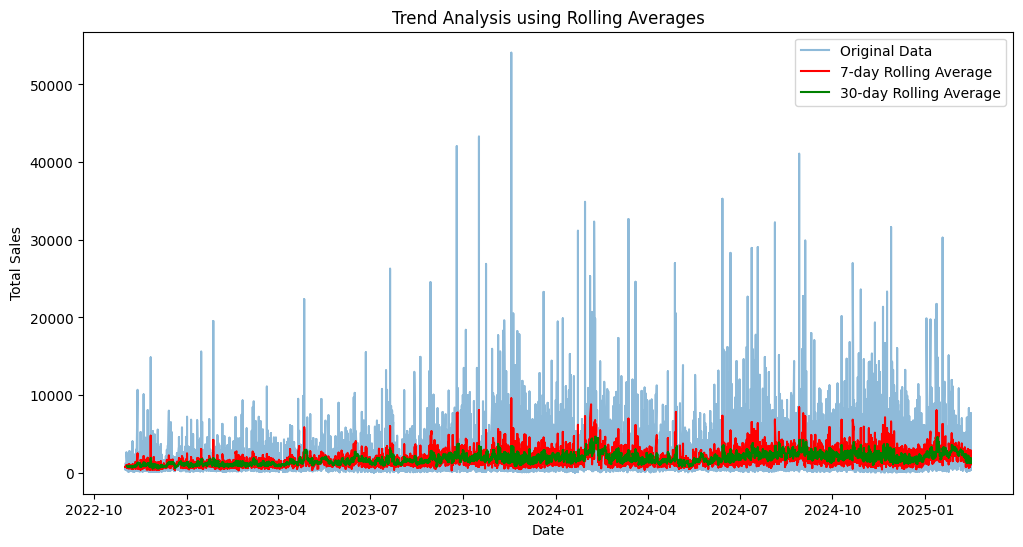

In [ ]:
df['rolling_7'] = df['Total'].rolling(window=7).mean()
df['rolling_30'] = df['Total'].rolling(window=30).mean()

plt.figure(figsize=(12,6))
plt.plot(df['Created at'], df['Total'], label="Original Data", alpha=0.5)
plt.plot(df['Created at'], df['rolling_7'], label="7-day Rolling Average", color='red')
plt.plot(df['Created at'], df['rolling_30'], label="30-day Rolling Average", color='green')
plt.xlabel("Date")
plt.ylabel("Total Sales")
plt.title("Trend Analysis using Rolling Averages")
plt.legend()
plt.show()


# Clustering Data Using K-Means

<ipython-input-40-d7a2ca156ba8>:6: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



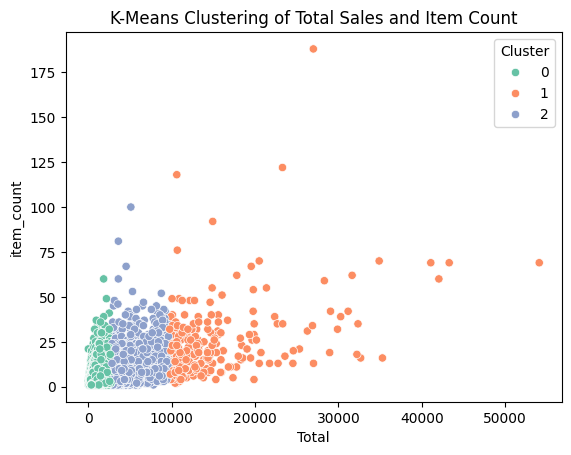

In [40]:
from sklearn.cluster import KMeans


df_cluster = df[['Total', 'item_count']]
kmeans = KMeans(n_clusters=3, random_state=42)
df_cluster['Cluster'] = kmeans.fit_predict(df_cluster)
sns.scatterplot(x=df_cluster['Total'], y=df_cluster['item_count'], hue=df_cluster['Cluster'], palette="Set2")
plt.title("K-Means Clustering of Total Sales and Item Count")
plt.show()


## 3. Interactive Graphs

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import holidays
from pytz import timezone
import regex as re
from datetime import datetime, timedelta
from dash import Dash, html, dcc
import plotly.express as px
import plotly.subplots as sp
import plotly.figure_factory as ff
import plotly.graph_objects as go
import plotly.colors as pc

/Users/ziadghanem/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


## GRAPHS FOR THE DATA

In [ ]:
df = pd.read_csv('depi_grouped.csv')

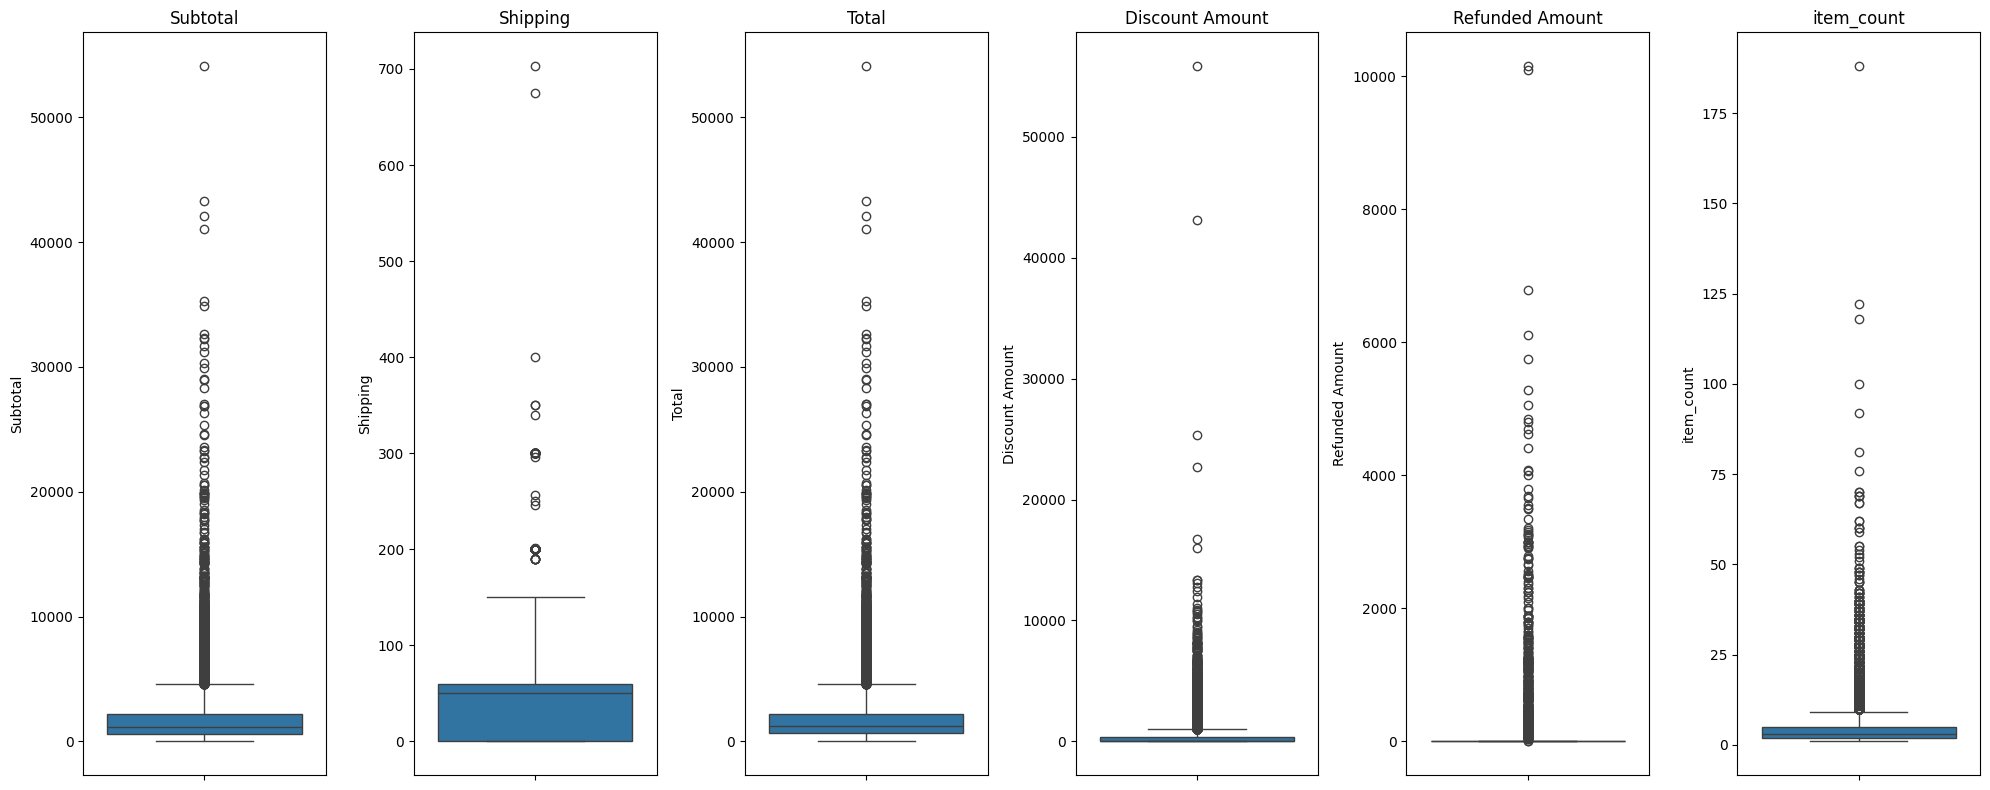

In [ ]:
numerical_columns = df.select_dtypes(include=['float64', 'int64']).columns

plt.figure(figsize=(20, 8))

for i, column in enumerate(numerical_columns, 1):
    plt.subplot(1, len(numerical_columns), i) 
    sns.boxplot(y=df[column])
    plt.title(column)
    
plt.tight_layout()
plt.show()

In [ ]:
fig = sp.make_subplots(rows=1, cols=len(numerical_columns))

for i, column in enumerate(numerical_columns, 1):
    fig.add_trace(go.Box(y=df[column], name=column), row=1, col=i)

fig.update_layout(
    title_text="Boxplots of Numerical Columns",
    showlegend=False,
    height=500,
    width=2000
)

fig.show()

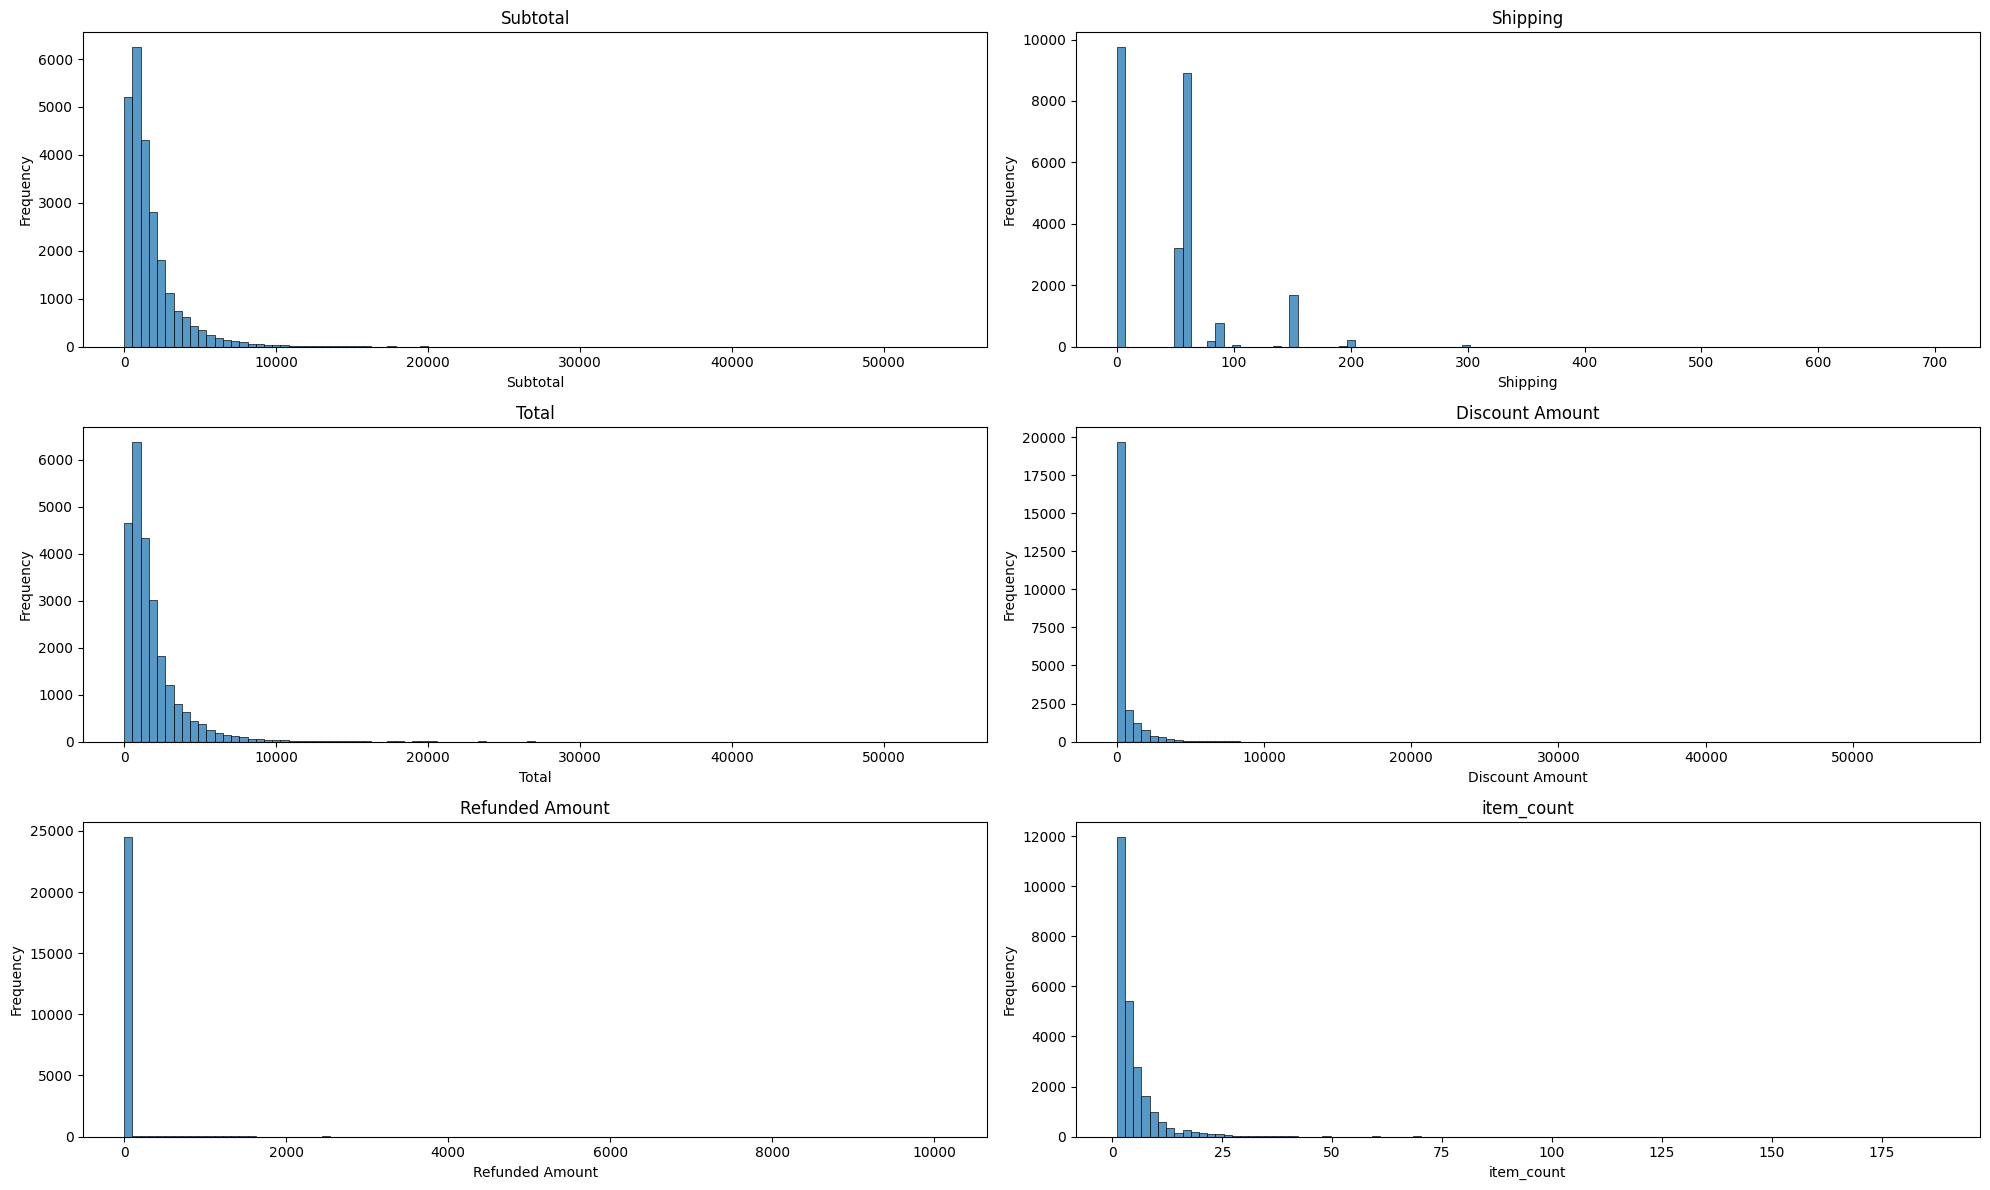

In [ ]:
numerical_columns = df.select_dtypes(include=['float64', 'int64']).columns

plt.figure(figsize=(20, 12))

num_cols = len(numerical_columns)
num_rows = (num_cols + 1) // 2 

for i, column in enumerate(numerical_columns, 1):
    plt.subplot(num_rows, 2, i)  
    sns.histplot(x=df[column], bins=100)
    plt.title(column)
    plt.xlabel(column)
    plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

In [ ]:
colors = pc.qualitative.Dark24[:len(numerical_columns)] 

fig = go.Figure()

for i, (column, color) in enumerate(zip(numerical_columns, colors)):
    fig.add_trace(
        go.Histogram(
            x=df[column], 
            name=column, 
            nbinsx=100, 
            opacity=1,
            marker_color=color,  
            visible=True if i == 0 else False  
        )
    )

dropdown_buttons = [
    {
        "label": column,
        "method": "update",
        "args": [
            {"visible": [i == j for j in range(len(numerical_columns))]},  
            {"title": f"<b>Interactive Histogram: {column}</b>"}
        ]
    }
    for i, column in enumerate(numerical_columns)
]

fig.update_layout(
    title=f"<b>Interactive Histogram: {numerical_columns[0]}</b>",
    xaxis_title="Value",
    yaxis_title="Frequency",
    updatemenus=[{
        "buttons": dropdown_buttons,
        "direction": "down",
        "showactive": True,
        "x": 1,
        "y": 1.10
    }],
    height=600,
    width=1280,
    barmode='overlay'
)

fig.show()



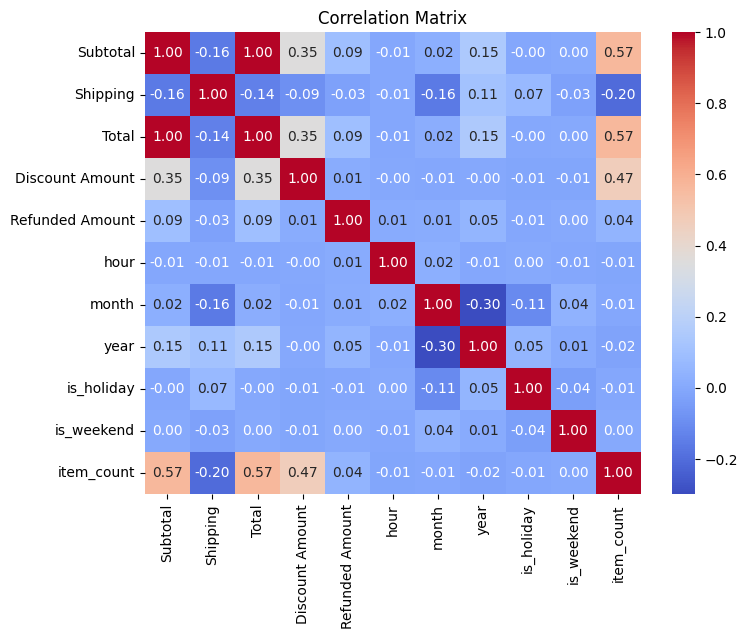

In [ ]:
corr = df.corr(numeric_only=True)
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()

In [ ]:
fig = ff.create_annotated_heatmap(
    z=corr.values, 
    x=list(corr.columns), 
    y=list(corr.index), 
    annotation_text=corr.round(2).values, 
    colorscale="tempo",
    showscale=True
)

fig.update_layout(title="Interactive Correlation Matrix", height=600, width=700)

fig.show()

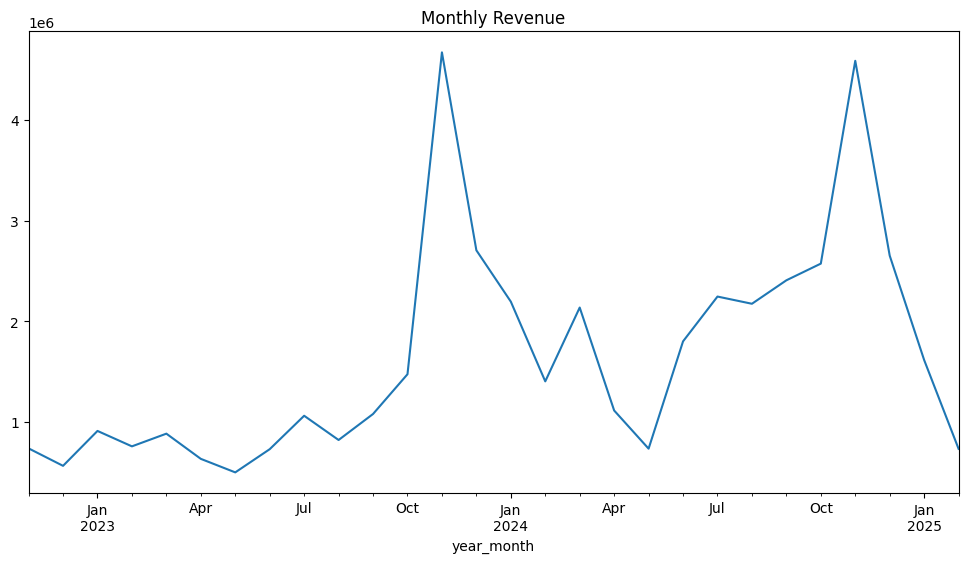

In [ ]:
monthly_revenue = df.groupby('year_month')['Total'].sum()
monthly_revenue.plot(kind='line', figsize=(12, 6), title='Monthly Revenue')
plt.show()

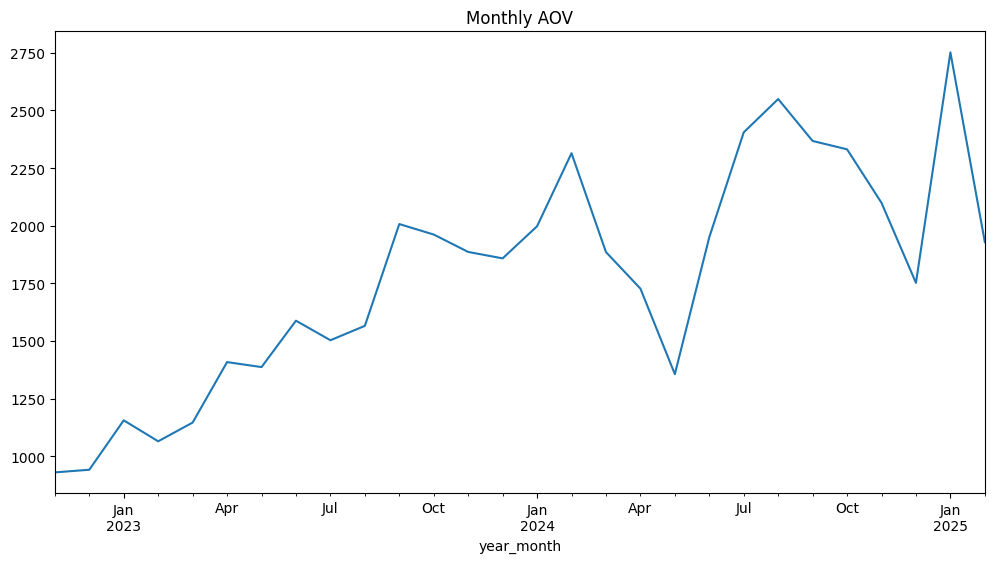

In [ ]:
monthly_aov = df.groupby('year_month')['Total'].mean()
monthly_aov.plot(kind='line', figsize=(12, 6), title='Monthly AOV')
plt.show()

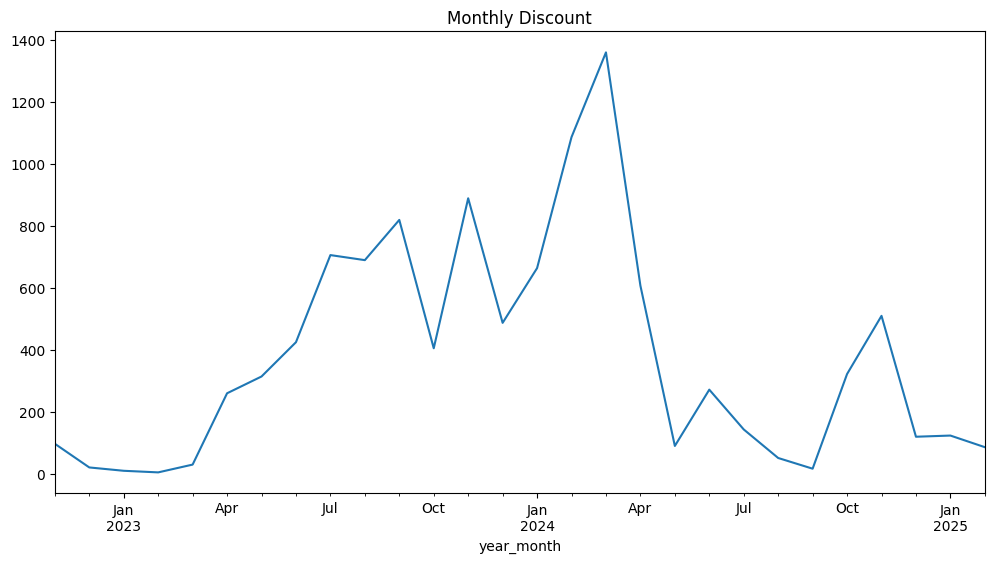

In [ ]:
monthly_discount = df.groupby('year_month')['Discount Amount'].mean()
monthly_discount.plot(kind='line', figsize=(12, 6), title='Monthly Discount')
plt.show()

In [ ]:
monthly_revenue.index = monthly_revenue.index.astype(str)
monthly_aov.index = monthly_aov.index.astype(str)
monthly_discount.index = monthly_discount.index.astype(str)

colors = ["blue", "green", "red"]

fig = go.Figure()

fig.add_trace(go.Scatter(
    x=monthly_revenue.index, y=monthly_revenue, 
    mode='lines+markers', name='Monthly Revenue', 
    line=dict(color=colors[0]), visible=True
))

fig.add_trace(go.Scatter(
    x=monthly_aov.index, y=monthly_aov, 
    mode='lines+markers', name='Monthly AOV', 
    line=dict(color=colors[1]), visible=False
))

fig.add_trace(go.Scatter(
    x=monthly_discount.index, y=monthly_discount, 
    mode='lines+markers', name='Monthly Discount', 
    line=dict(color=colors[2]), visible=False
))

fig.update_layout(
    title="Monthly Metrics Overview",
    xaxis_title="Year-Month",
    yaxis_title="Value",
    height=600,
    width=900,
    hovermode="x unified",
    updatemenus=[
        {
            "buttons": [
                {"label": "Monthly Revenue", "method": "update", 
                 "args": [{"visible": [True, False, False]}, {"title": "Monthly Revenue"}]},
                {"label": "Monthly AOV", "method": "update", 
                 "args": [{"visible": [False, True, False]}, {"title": "Monthly AOV"}]},
                {"label": "Monthly Discount", "method": "update", 
                 "args": [{"visible": [False, False, True]}, {"title": "Monthly Discount"}]},
            ],
            "direction": "down",
            "showactive": True
        }
    ]
)

fig.show()


Lineitem name
Plain Towels 500GSM - 30x30 / Off White    980
Pillow Protector - WHITE / 50*70           833
Plain Towels 500GSM - 30x30 / Grey         824
Plain Towels 500GSM - 30x30 / White        813
Plain Towels 500GSM - 30x30 / Coffee       664
Pillow Protector - GREY / 50*70            663
Plain Towels 500GSM - 30x30 / Mint         634
Golden Christmas Hand Towel                566
Mattress Protector - 180x200 / White       520
Olivia Kitchen Towel 30x50cm - Coffee      503
Olivia Kitchen Towel 30x50cm - Navy        499
Mattress Protector - 120x200 / White       477
Plain Towels 500GSM - 30x30 / Navy         474
Mattress Protector - 160x200 / White       470
Diamond Towel - 30x30 / Off White          460
Hollow Fiber Pillow - 1000gm               459
Waffle Towel - 30x30 / Navy                459
Waffle Towel - 30x30 / Off White           458
Mattress Protector - 180x200 / Grey        445
Waffle Towel - 30x30 / Mint                444
Name: Lineitem quantity, dtype: int64

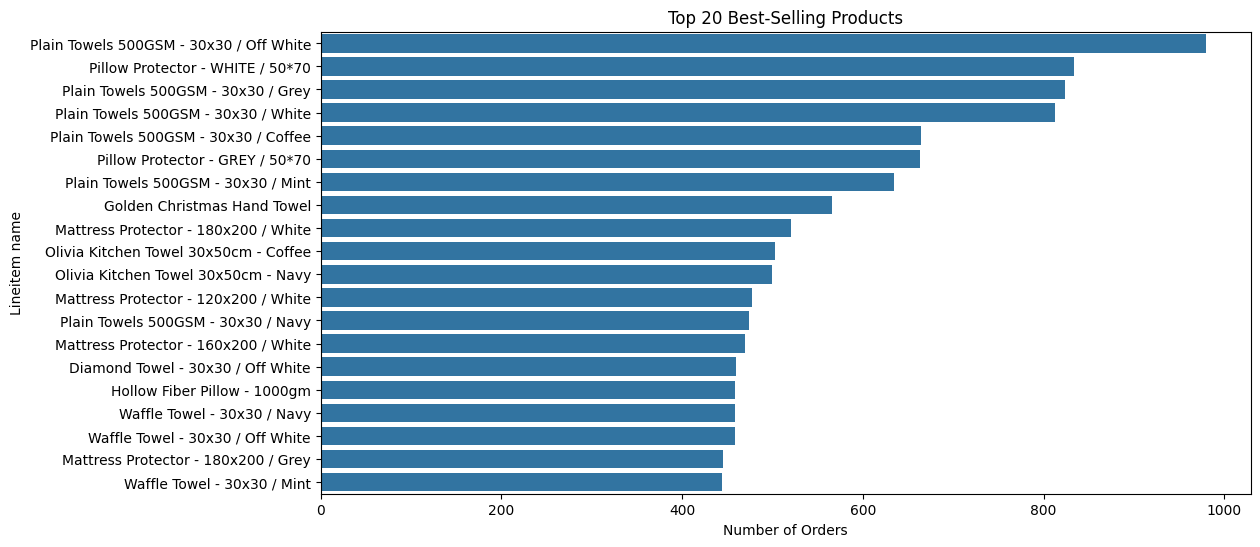

In [ ]:
all_products = df['Lineitem name'].explode()
all_products = pd.concat([all_products,df['Lineitem quantity'].explode()],axis=1)
all_products['Lineitem quantity'] = pd.to_numeric(all_products['Lineitem quantity'], errors='coerce')

top_products = all_products.groupby('Lineitem name')['Lineitem quantity'].sum().sort_values(ascending=False).head(20)
    

plt.figure(figsize=(12,6))
sns.barplot(x=top_products.values, y=top_products.index)
plt.title('Top 20 Best-Selling Products')
plt.xlabel('Number of Orders')
top_products

In [ ]:
all_products = df['Lineitem name'].explode()
all_products = pd.concat([all_products, df['Lineitem quantity'].explode()], axis=1)

all_products['Lineitem quantity'] = pd.to_numeric(all_products['Lineitem quantity'], errors='coerce')

top_products = all_products.groupby('Lineitem name')['Lineitem quantity'].sum().sort_values(ascending=False).head(20)

fig = px.bar(
    top_products, 
    x=top_products.values, 
    y=top_products.index, 
    orientation='h',
    title="Top 20 Best-Selling Products",
    labels={'x': 'Number of Orders', 'y': 'Product Name'},
    text=top_products.values,
)

fig.update_layout(
    xaxis_title="Number of Orders", 
    yaxis_title="Product Name", 
    height=600, 
    width=900,
    yaxis={'categoryorder':'total ascending'}
)

fig.update_traces(marker_color='royalblue', textposition='outside')

fig.show()

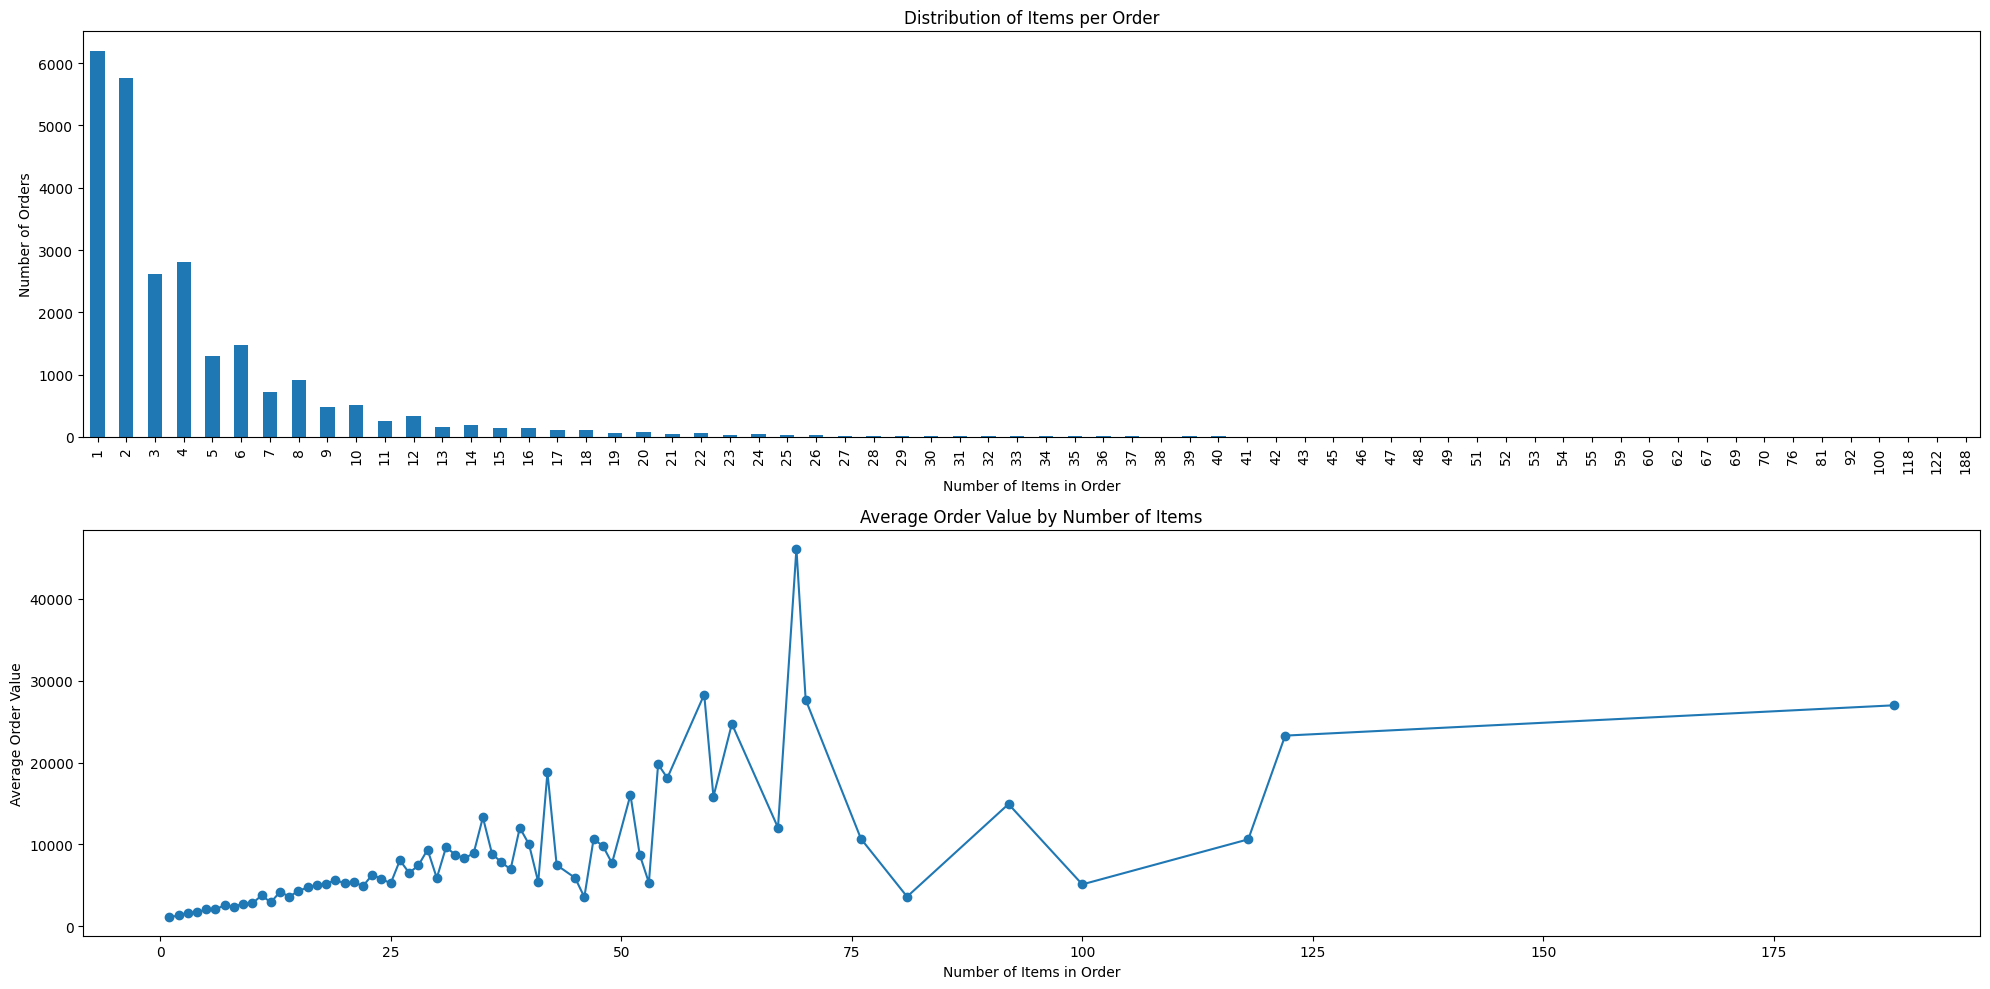


Order Size Summary:
Most common order size: 1 items
Average order size: 4.47 items
Maximum items in an order: 188
Minimum items in an order: 1


In [ ]:
plt.figure(figsize=(20, 10))
# Distribution of order sizes
plt.subplot(2, 1, 1)
df['item_count'].value_counts().sort_index().plot(kind='bar')
plt.title('Distribution of Items per Order')
plt.xlabel('Number of Items in Order')
plt.ylabel('Number of Orders')

# Average order value by number of items
plt.subplot(2, 1, 2)
avg_order_value = df.groupby('item_count')['Total'].mean()
avg_order_value.plot(kind='line', marker='o')
plt.title('Average Order Value by Number of Items')
plt.xlabel('Number of Items in Order')
plt.ylabel('Average Order Value')

plt.tight_layout()
plt.show()

# Summary statistics
print("\nOrder Size Summary:")
print(f"Most common order size: {df['item_count'].mode().values[0]} items")
print(f"Average order size: {df['item_count'].mean():.2f} items")
print(f"Maximum items in an order: {df['item_count'].max()}")
print(f"Minimum items in an order: {df['item_count'].min()}")



In [ ]:
order_size_counts = df['item_count'].value_counts().sort_index()

avg_order_value = df.groupby('item_count')['Total'].mean()

fig = sp.make_subplots(
    rows=2, cols=1, 
    subplot_titles=["Distribution of Items per Order", "Average Order Value by Number of Items"]
)

fig.add_trace(
    go.Bar(x=order_size_counts.index, y=order_size_counts.values, name="Order Size Distribution"),
    row=1, col=1
)

fig.add_trace(
    go.Scatter(x=avg_order_value.index, y=avg_order_value.values, mode='lines+markers', name="Average Order Value"),
    row=2, col=1
)

fig.update_layout(
    height=800, width=1280, 
    title_text="Order Size and Value Analysis",
    xaxis_title="Number of Items in Order",
    yaxis_title="Number of Orders",
    showlegend=False
)

fig.show()

print("\nOrder Size Summary:")
print(f"Most common order size: {df['item_count'].mode().values[0]} items")
print(f"Average order size: {df['item_count'].mean():.2f} items")
print(f"Maximum items in an order: {df['item_count'].max()}")
print(f"Minimum items in an order: {df['item_count'].min()}")


Order Size Summary:
Most common order size: 1 items
Average order size: 4.47 items
Maximum items in an order: 188
Minimum items in an order: 1


In [ ]:
day_analysis = df.groupby('day_type').agg({
    'Total': ['count', 'mean', 'sum'],
    'item_count': ['sum'] 
}).round(2)

day_analysis.columns = ['count', 'mean', 'sum', 'items_count']

day_analysis = day_analysis.reindex(['Holiday', 'Weekday', 'Weekend'])

print("\nSales Analysis by Day Type:")
print(day_analysis)


print("\nItem Analysis:")
print(f"Average items per order: {df['item_count'].mean():.2f}")
print(f"Maximum items in an order: {df['item_count'].max()}")
print(f"Minimum items in an order: {df['item_count'].min()}")


Sales Analysis by Day Type:
          count     mean          sum  items_count
day_type                                          
Holiday     843  1804.65   1521319.14         3610
Weekday   16740  1839.30  30789799.99        74769
Weekend    7273  1858.90  13519792.57        32605

Item Analysis:
Average items per order: 4.47
Maximum items in an order: 188
Minimum items in an order: 1


In [ ]:

yearly_orders = df.groupby('year').agg({
    'Name': 'count',
    'Total': 'sum'
}).rename(columns={'Name': 'order_count'})

seasonal_analysis = df.groupby('season',observed=False).agg({
    'Name': 'count',
    'Total': ['mean', 'sum'],
})
seasonal_orders = df.groupby(['year', 'season'],observed=False)['Total'].sum().unstack()


monthly_trend = df.groupby('year_month').agg({
    'Name': 'count',
    'Total': 'sum'
})

province_yearly = df.groupby(['year', 'Shipping Province Name']).agg({
    'Name': 'count',
    'Total': 'sum'
})

pivot_province = province_yearly.reset_index().pivot(
    index='Shipping Province Name', 
    columns='year', 
    values='Total'
)



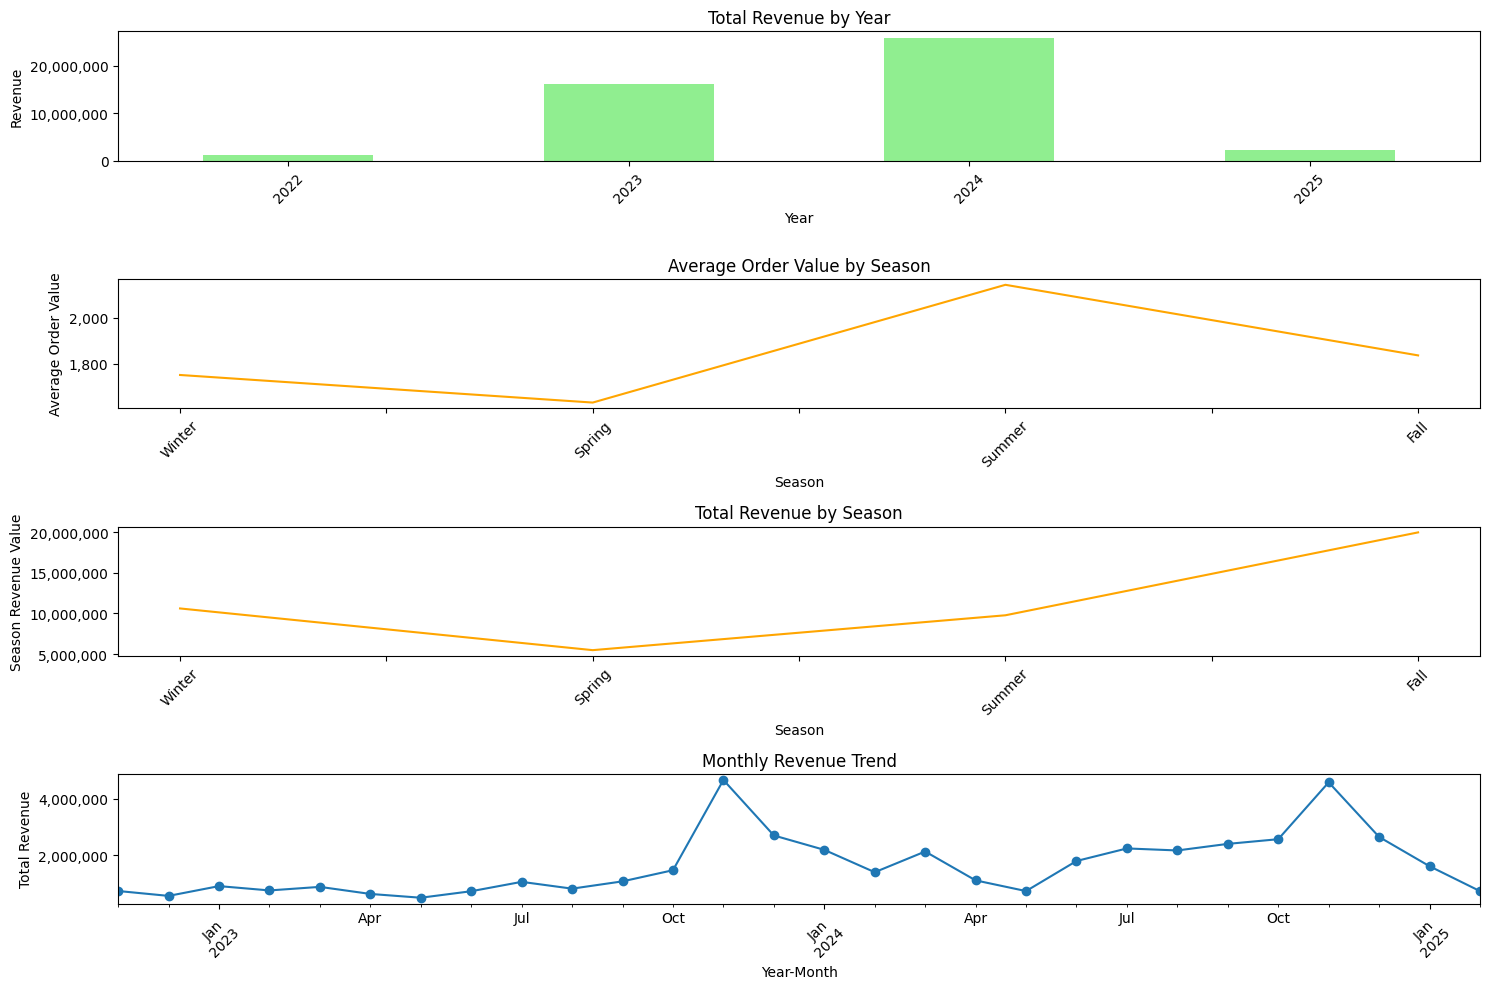

In [ ]:
plt.figure(figsize=(15, 10))

# Yearly revenue subplot
plt.subplot(4, 1, 1)
ax1 = yearly_orders['Total'].plot(kind='bar', y='Total', color='lightgreen')
plt.title('Total Revenue by Year')
plt.xlabel('Year')
plt.ylabel('Revenue')
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: format(int(x), ',')))
plt.xticks(rotation=45)

#  Seasonal Analysis
plt.subplot(4, 1, 2)
ax2 = seasonal_analysis['Total']['mean'].plot(kind='line',y='mean', color='orange')
plt.title('Average Order Value by Season')
plt.xlabel('Season')
plt.ylabel('Average Order Value')
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: format(int(x), ',')))
plt.xticks(rotation=45)

#  Seasonal Analysis
plt.subplot(4, 1, 3)
ax3 = seasonal_analysis['Total']['sum'].plot(kind='line',y='sum', color='orange')
plt.title('Total Revenue by Season')
plt.xlabel('Season')
plt.ylabel('Season Revenue Value')
ax3.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: format(int(x), ',')))
plt.xticks(rotation=45)

#  Monthly Trend
plt.subplot(4,1, 4)
ax4 = monthly_trend['Total'].plot(kind='line', marker='o')
plt.title('Monthly Revenue Trend')
plt.xlabel('Year-Month')
plt.ylabel('Total Revenue')
ax4.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: format(int(x), ',')))
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()



In [ ]:
yearly_orders.index = yearly_orders.index.astype(str)
seasonal_analysis.index = seasonal_analysis.index.astype(str)
monthly_trend.index = monthly_trend.index.astype(str)

fig = sp.make_subplots(
    rows=4, cols=1, 
    subplot_titles=[
        "Total Revenue by Year",
        "Average Order Value by Season",
        "Total Revenue by Season",
        "Monthly Revenue Trend"
    ],
    vertical_spacing=0.15
)

fig.add_trace(
    go.Bar(x=yearly_orders.index, y=yearly_orders['Total'], marker_color="lightgreen", name="Total Revenue"),
    row=1, col=1
)

fig.add_trace(
    go.Scatter(x=seasonal_analysis.index, y=seasonal_analysis['Total']['mean'], 
               mode='lines+markers', line=dict(color="orange"), name="Avg Order Value"),
    row=2, col=1
)

fig.add_trace(
    go.Scatter(x=seasonal_analysis.index, y=seasonal_analysis['Total']['sum'], 
               mode='lines+markers', line=dict(color="red"), name="Total Revenue"),
    row=3, col=1
)

fig.add_trace(
    go.Scatter(x=monthly_trend.index, y=monthly_trend['Total'], 
               mode='lines+markers', line=dict(color="blue"), name="Monthly Revenue"),
    row=4, col=1
)

fig.update_layout(
    height=1000, width=1280, 
    title="Revenue & Seasonal Analysis",
    showlegend=False,  
    xaxis4=dict(title="Year-Month"),
    xaxis3=dict(title="Season"),
    xaxis2=dict(title="Season"),
    xaxis1=dict(title="Year"),
    yaxis1=dict(title="Revenue"),
    yaxis2=dict(title="Average Order Value"),
    yaxis3=dict(title="Total Revenue"),
    yaxis4=dict(title="Total Revenue"),
)

fig.show()

<Figure size 1500x1000 with 0 Axes>

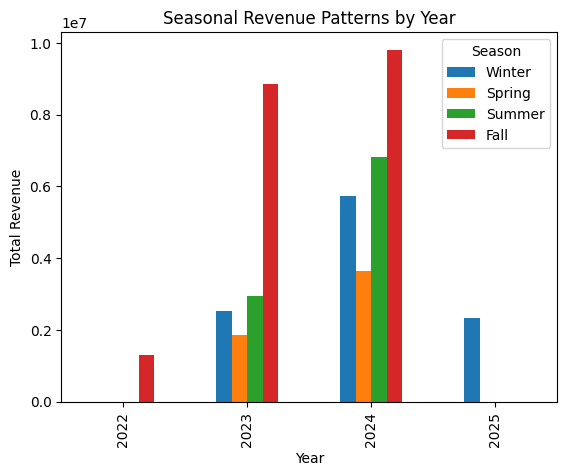

In [ ]:
plt.figure(figsize=(15,10))


seasonal_orders.plot(kind='bar')
plt.title('Seasonal Revenue Patterns by Year')
plt.xlabel('Year')
plt.ylabel('Total Revenue')
plt.legend(title='Season')

plt.show()

In [ ]:
seasonal_orders.index = seasonal_orders.index.astype(str)

fig = px.bar(
    seasonal_orders, 
    x=seasonal_orders.index, 
    y=seasonal_orders.columns,  
    title="Seasonal Revenue Patterns by Year",
    labels={"value": "Total Revenue", "variable": "Season", "x": "Year"},
    barmode="group"
)

fig.update_layout(
    xaxis_title="Year",
    yaxis_title="Total Revenue",
    legend_title="Season",
    height=600,
    width=900
)

fig.show()

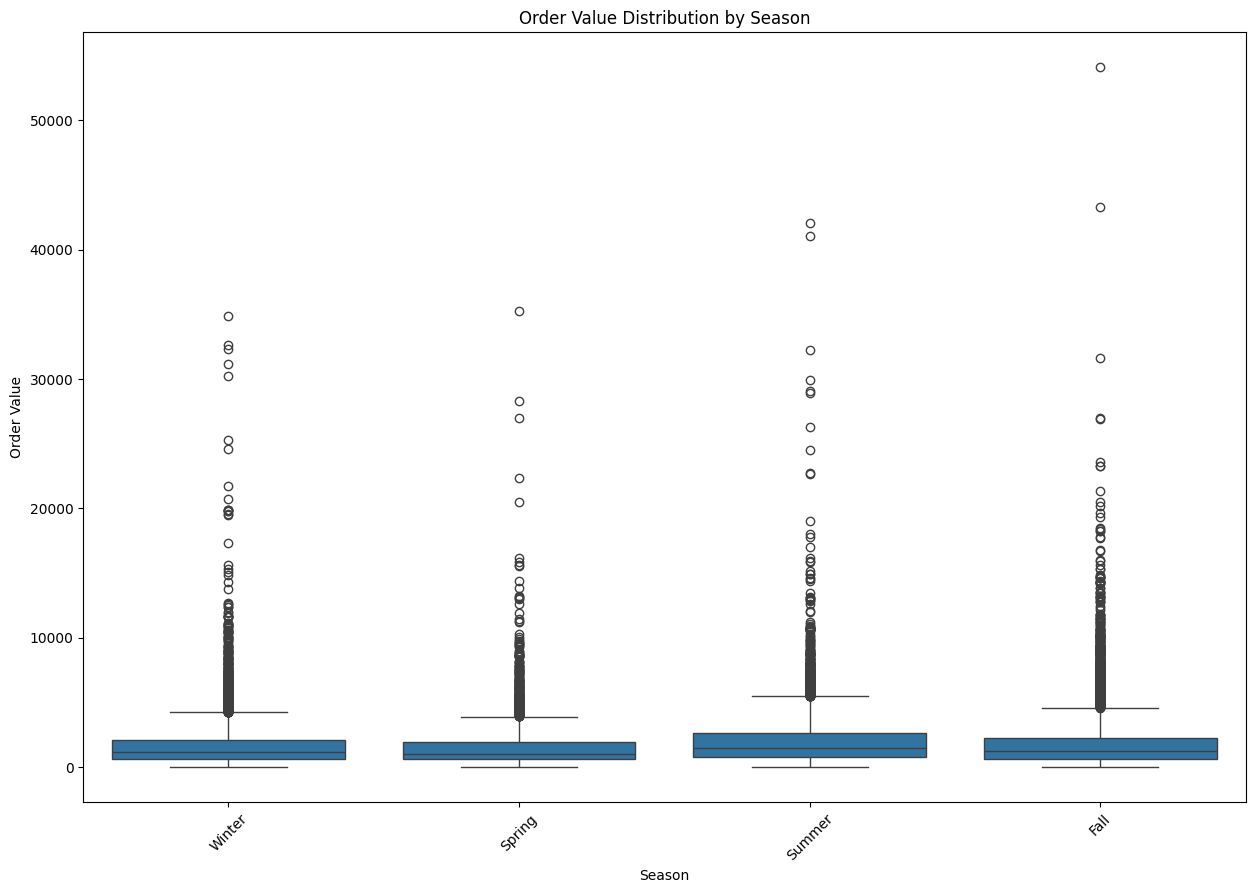

In [ ]:
plt.figure(figsize=(15, 10))
sns.boxplot(data=df, x='season', y='Total')
plt.title('Order Value Distribution by Season')
plt.xlabel('Season')
plt.ylabel('Order Value')
plt.xticks(rotation=45)

plt.show()

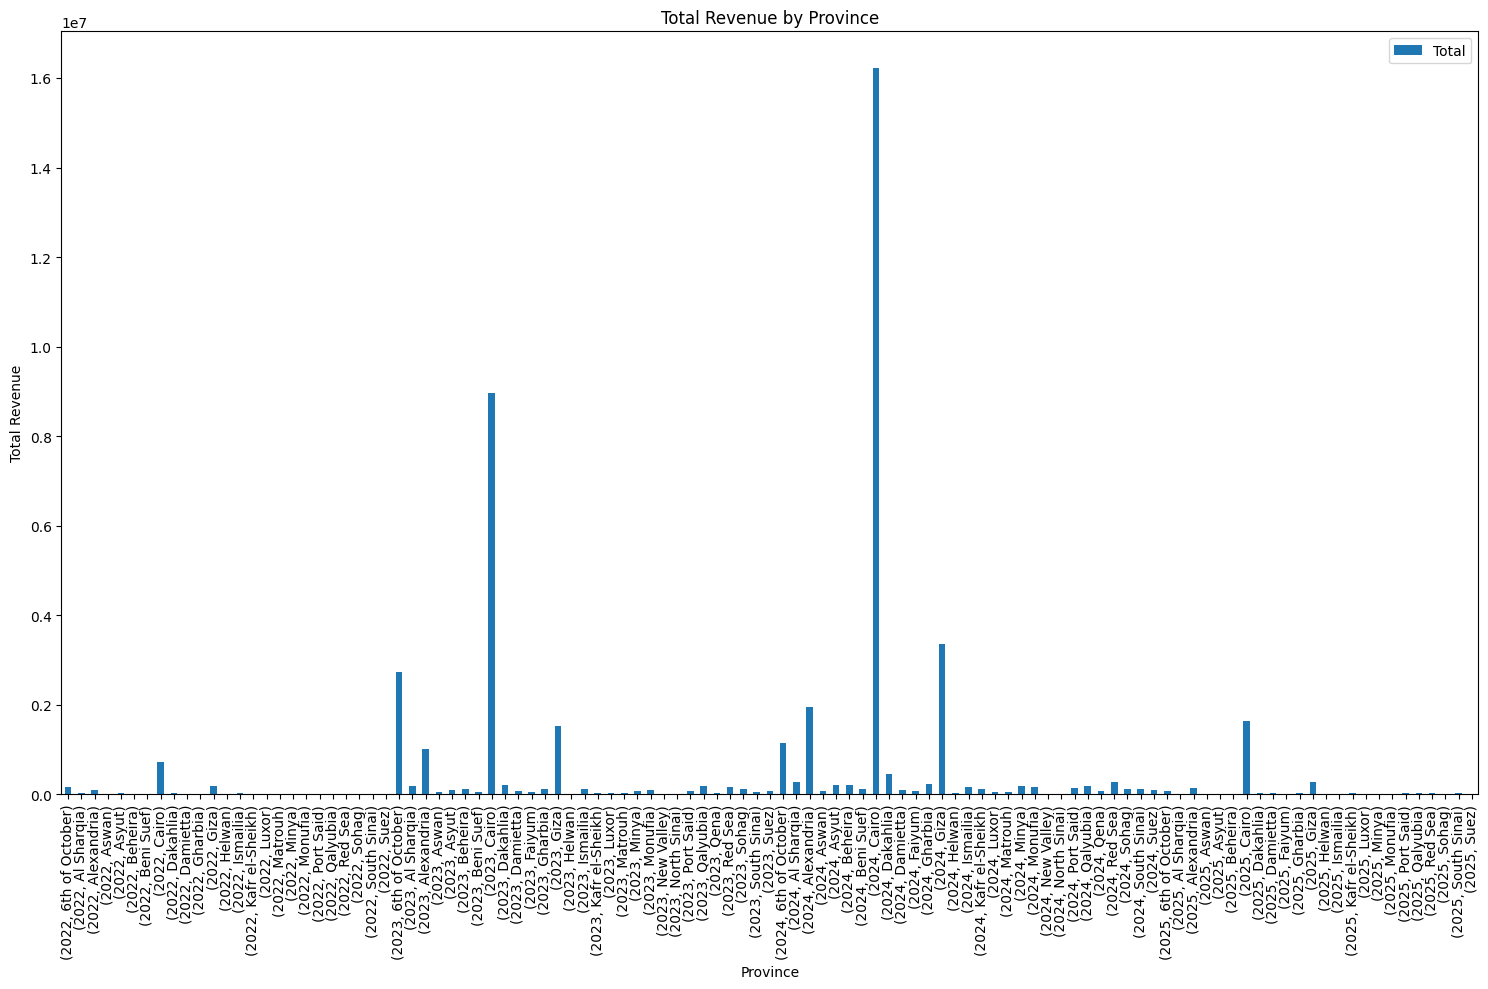

In [ ]:
province_yearly.plot(kind='bar', y='Total', figsize=(15, 10))
plt.title('Total Revenue by Province')
plt.xlabel('Province')
plt.ylabel('Total Revenue')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

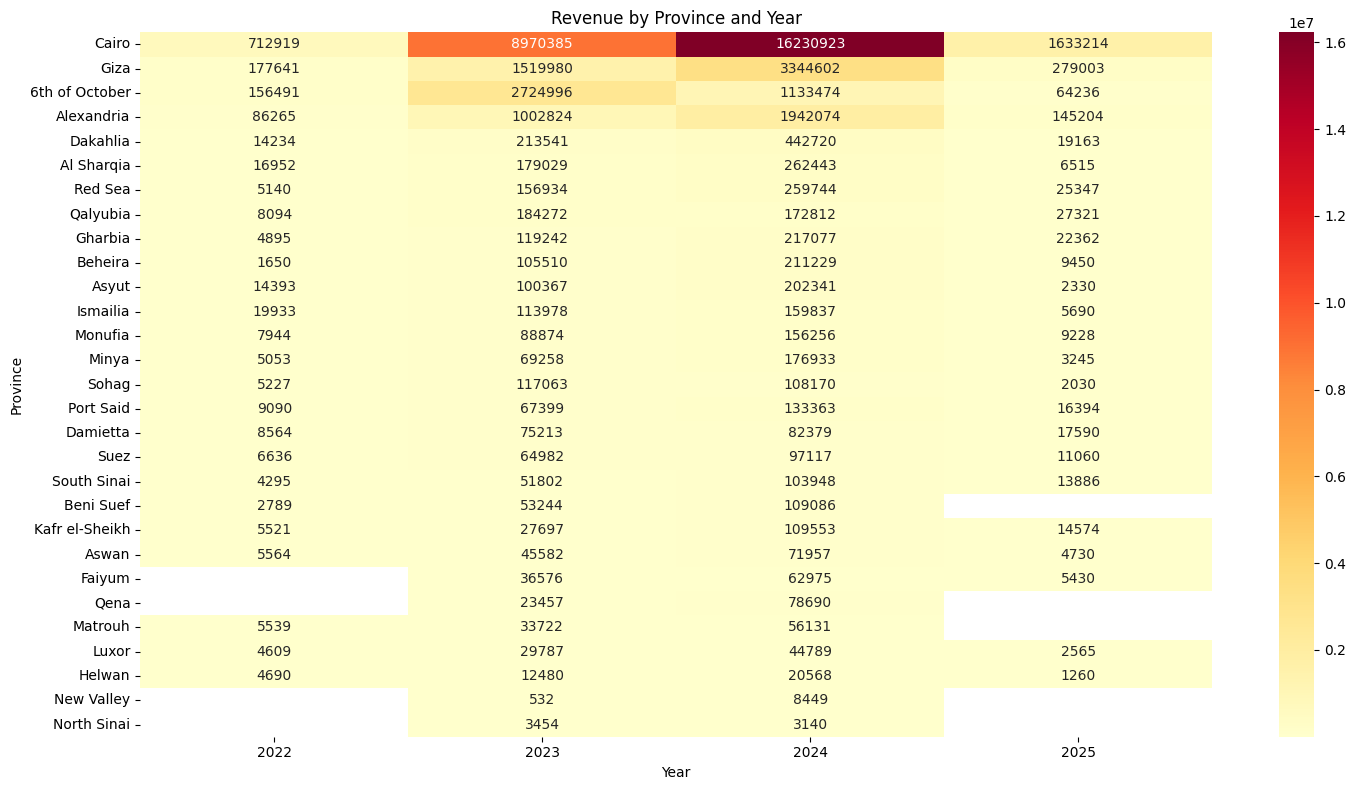

In [ ]:

plt.figure(figsize=(15, 8))
province_totals = pivot_province.sum(axis=1).sort_values(ascending=False)
pivot_province_sorted = pivot_province.reindex(province_totals.index)
sns.heatmap(pivot_province_sorted, annot=True, fmt='.0f', cmap='YlOrRd')
plt.title('Revenue by Province and Year')
plt.xlabel('Year')
plt.ylabel('Province')
plt.tight_layout()
plt.show()


In [ ]:
yoy_growth = ((yearly_orders - yearly_orders.shift(1)) / yearly_orders.shift(1)) * 100

mom_growth = ((monthly_trend - monthly_trend.shift(1)) / monthly_trend.shift(1)) * 100



product_prices = []
for idx, row in df.iterrows():
    year = row['Created at'].year
    for price, product in zip(row['Lineitem price'], row['Lineitem name']):
        product_prices.append({
            'year': year,
            'product': product,
            'price': price
        })

product_df = pd.DataFrame(product_prices)

yearly_prices = product_df.groupby(['year', 'product'])['price'].mean().reset_index()

price_pivot = yearly_prices.pivot(index='product', columns='year', values='price')

yoy_changes = pd.DataFrame()
for year in range(price_pivot.columns.min()+1, price_pivot.columns.max()+1):
    
    yoy = ((price_pivot[year] - price_pivot[year-1]) / price_pivot[year-1] * 100)

    yoy = yoy.replace([np.inf, -np.inf], np.nan)
    yoy_changes[f'{year}_YoY%'] = yoy

    

final_analysis = pd.concat([price_pivot, yoy_changes], axis=1)

final_analysis = final_analysis.sort_index()




yoy_changes['Avg_Change'] = yoy_changes.abs().mean(axis=1)
print("\nOverall Price Change Statistics:")
for year in yoy_changes.columns:
    if year != 'Avg_Change':
        print(f"\nYear {year}:")
        print(f"Average Change: {yoy_changes[year].mean():.2f}%")
        print(f"Median Change: {yoy_changes[year].median():.2f}%")
        print(f"Max Increase: {yoy_changes[year].max():.2f}%")
        print(f"Max Decrease: {yoy_changes[year].min():.2f}%")




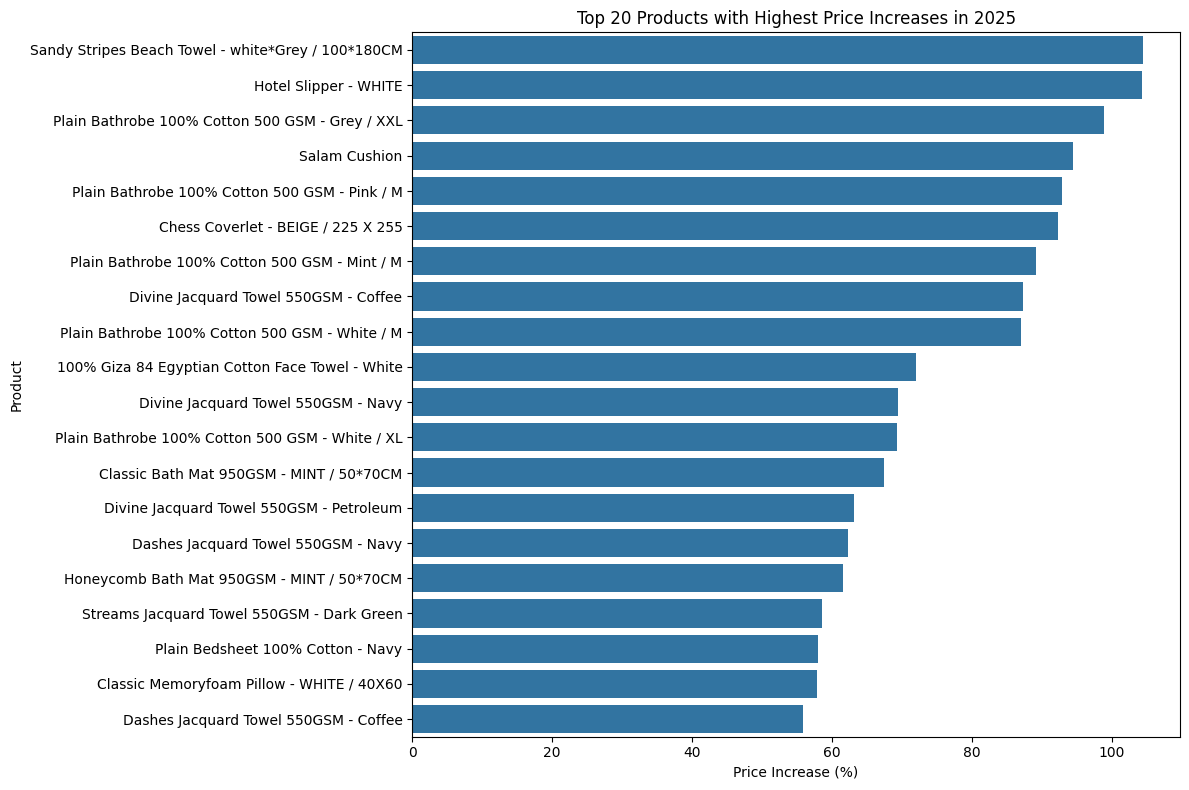

In [ ]:
plt.figure(figsize=(12,8))

latest_year = f'{price_pivot.columns.max()}_YoY%'
top_20_increases = yoy_changes[latest_year].sort_values(ascending=False).head(20)

sns.barplot(x=top_20_increases.values, y=top_20_increases.index)
plt.title(f'Top 20 Products with Highest Price Increases in {price_pivot.columns.max()}')
plt.xlabel('Price Increase (%)')
plt.ylabel('Product')
plt.tight_layout()
plt.show()

In [ ]:
latest_year = f'{price_pivot.columns.max()}_YoY%'

top_20_increases = yoy_changes[latest_year].sort_values(ascending=False).head(20)

fig = px.bar(
    x=top_20_increases.values,
    y=top_20_increases.index,  
    orientation="h",  
    title=f"Top 20 Products with Highest Price Increases in {price_pivot.columns.max()}",
    labels={"x": "Price Increase (%)", "y": "Product"},
    color=top_20_increases.values, 
    color_continuous_scale="Reds"
)

fig.update_layout(
    xaxis_title="Price Increase (%)",
    yaxis_title="Product",
    height=600,
    width=900,
    yaxis=dict(categoryorder="total ascending")
)

fig.show()


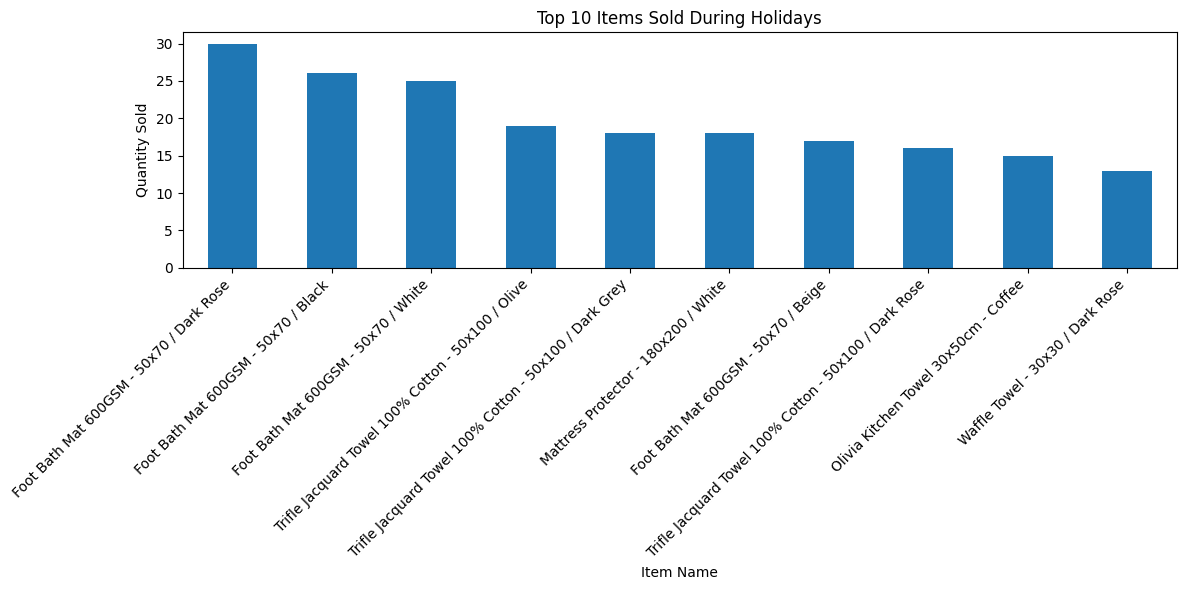

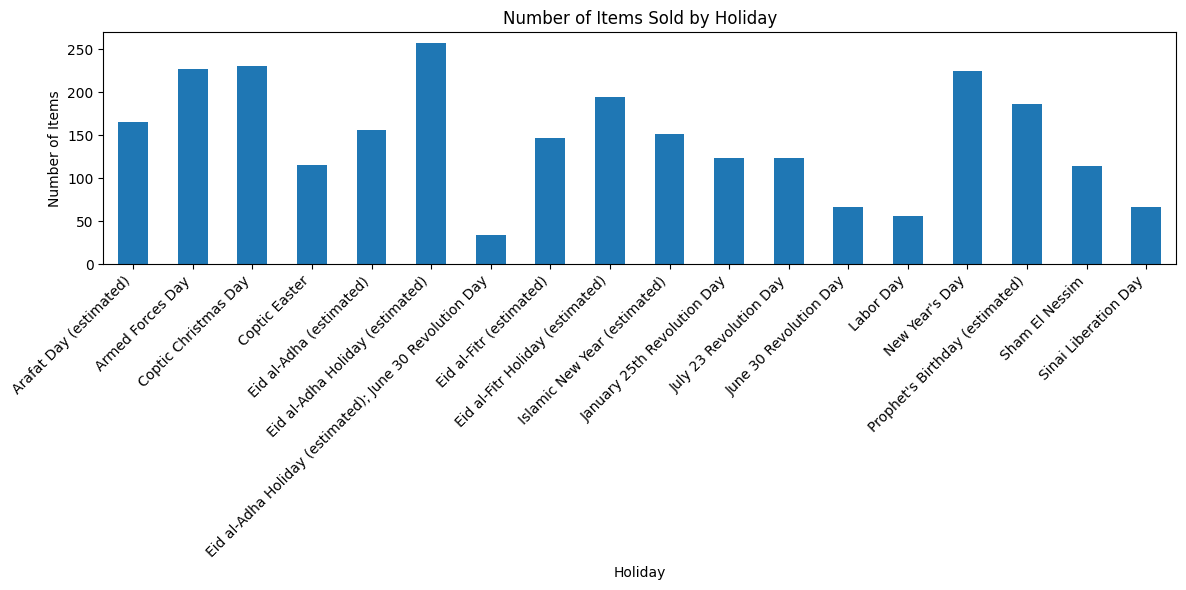

In [ ]:
if df['is_holiday'].any():
    holiday_items = []
    
    # Process each holiday order
    holiday_orders = df[df['is_holiday']]
    for _, row in holiday_orders.iterrows():
        items = row['Lineitem name']
        prices = row['Lineitem price']
        holiday = row['holiday_name']

        for item, price in zip(items, prices):
            holiday_items.append({
                'holiday': holiday,
                'item': item.strip(),
                'price': float(price),
                'date': row['Created at']
            })
    
    holiday_items_df = pd.DataFrame(holiday_items)
    

    holiday_analysis = holiday_items_df.groupby(['holiday', 'item']).agg({
        'item': 'count',
        'price': ['mean', 'sum']
    }).round(2)
    
    holiday_analysis.columns = ['quantity_sold', 'avg_price', 'total_revenue']
    

    
    # Top items sold during holidays
    top_holiday_items = holiday_items_df.groupby('item')['item'].count().sort_values(ascending=False).head(10)
    
    plt.figure(figsize=(12, 6))
    top_holiday_items.plot(kind='bar')
    plt.title('Top 10 Items Sold During Holidays')
    plt.xlabel('Item Name')
    plt.ylabel('Quantity Sold')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
    
    # Sales distribution by holiday
    plt.figure(figsize=(12, 6))
    holiday_items_df.groupby('holiday')['item'].count().plot(kind='bar')
    plt.title('Number of Items Sold by Holiday')
    plt.xlabel('Holiday')
    plt.ylabel('Number of Items')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()


In [ ]:
if df['is_holiday'].any():
    holiday_items = []

    holiday_orders = df[df['is_holiday']]
    for _, row in holiday_orders.iterrows():
        items = row['Lineitem name']
        prices = row['Lineitem price']
        holiday = row['holiday_name']

        for item, price in zip(items, prices):
            holiday_items.append({
                'holiday': holiday,
                'item': item.strip(),
                'price': float(price),
                'date': row['Created at']
            })

    holiday_items_df = pd.DataFrame(holiday_items)

    holiday_analysis = holiday_items_df.groupby(['holiday', 'item']).agg({
        'item': 'count',
        'price': ['mean', 'sum']
    }).round(2)
    
    holiday_analysis.columns = ['quantity_sold', 'avg_price', 'total_revenue']

    top_holiday_items = holiday_items_df.groupby('item')['item'].count().sort_values(ascending=False).head(10)
    fig1 = px.bar(
        x=top_holiday_items.index,
        y=top_holiday_items.values,
        title="Top 10 Items Sold During Holidays",
        labels={"x": "Item Name", "y": "Quantity Sold"},
        color=top_holiday_items.values,
        color_continuous_scale="Blues"
    )
    fig1.update_layout(xaxis_tickangle=-45, height=500, width=1280)
    fig1.show()

    holiday_sales = holiday_items_df.groupby('holiday')['item'].count()
    fig2 = px.bar(
        x=holiday_sales.index,
        y=holiday_sales.values,
        title="Number of Items Sold by Holiday",
        labels={"x": "Holiday", "y": "Number of Items"},
        color=holiday_sales.values,
        color_continuous_scale="Oranges"
    )
    fig2.update_layout(xaxis_tickangle=-45, height=500, width=1280)
    fig2.show()

Text(0, 0.5, 'Frequency')

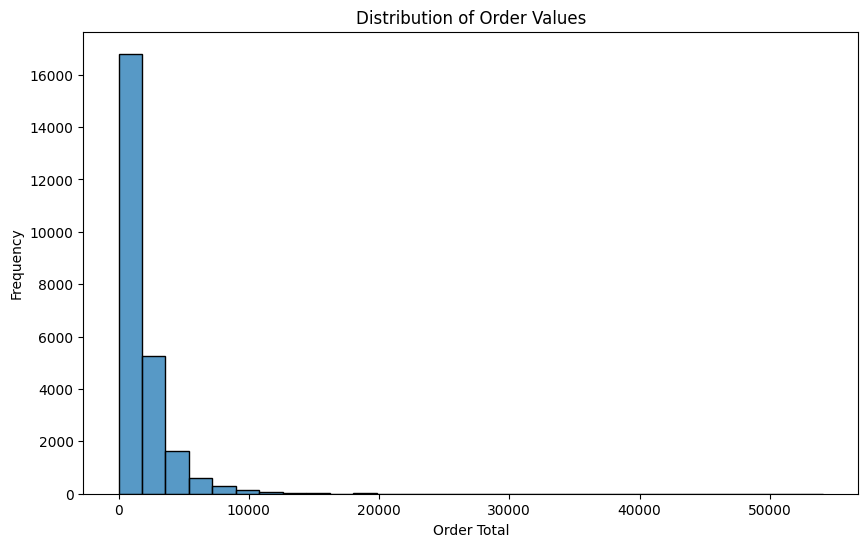

In [ ]:
plt.figure(figsize=(10,6))
sns.histplot(df['Subtotal'], bins=30)
plt.title('Distribution of Order Values')
plt.xlabel('Order Total')
plt.ylabel('Frequency')

In [ ]:
fig = px.histogram(
    df, 
    x="Subtotal", 
    nbins=30, 
    title="Distribution of Order Values", 
    labels={"Subtotal": "Order Total", "count": "Frequency"}, 
    color_discrete_sequence=["royalblue"]
)

fig.update_layout(
    bargap=0.1,
    height=500, width=800
)

fig.show()